# PART 1 - Import Library, Config dan Load Data

## 1A - Import Library

In [1]:
# BAGIAN 1a — IMPORT LIBRARY
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Seed       : {SEED}")
print("\nSemua library berhasil diimport.")
print("Variabel tersedia untuk 01b: SEED dan semua library")

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.3.3
Seed       : 42

Semua library berhasil diimport.
Variabel tersedia untuk 01b: SEED dan semua library


## 1B - Config Path Hyperparameter

In [2]:
# BAGIAN 1b — KONFIGURASI PATH DAN HYPERPARAMETER

BASE_DIR   = "/kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix"
WC_DIR     = os.path.join(BASE_DIR, "working_conditions")
TA_DIR     = os.path.join(BASE_DIR, "test_anomaly")
LIST_OF_TESTS_PATH = os.path.join(BASE_DIR, "List_of_tests.xlsx")
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# HYPERPARAMETER MODEL
TIMESTEPS  = 30    
BATCH_SIZE = 32   
EPOCHS     = 100  
LATENT_DIM = 32    
DROPOUT    = 0.2   

print("Konfigurasi path:")
print(f"  WC_DIR     : {WC_DIR}")
print(f"  TA_DIR     : {TA_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")
print("\nHyperparameter model:")
print(f"  TIMESTEPS  : {TIMESTEPS}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  EPOCHS     : {EPOCHS}")
print(f"  LATENT_DIM : {LATENT_DIM}")
print(f"  DROPOUT    : {DROPOUT}")
print("\nVariabel tersedia untuk 01c: BASE_DIR, WC_DIR, TA_DIR, OUTPUT_DIR,")
print("  TIMESTEPS, BATCH_SIZE, EPOCHS, LATENT_DIM, DROPOUT")

Konfigurasi path:
  WC_DIR     : /kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix/working_conditions
  TA_DIR     : /kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix/test_anomaly
  OUTPUT_DIR : /kaggle/working

Hyperparameter model:
  TIMESTEPS  : 30
  BATCH_SIZE : 32
  EPOCHS     : 100
  LATENT_DIM : 32
  DROPOUT    : 0.2

Variabel tersedia untuk 01c: BASE_DIR, WC_DIR, TA_DIR, OUTPUT_DIR,
  TIMESTEPS, BATCH_SIZE, EPOCHS, LATENT_DIM, DROPOUT


## 1C - Experiment Design

In [3]:
# BAGIAN 1c — DESAIN EKSPERIMEN

# Grup A: setpoint identik dengan semua file anomali
GROUP_A = [
    "working_condition1.xlsx",      # V1=5.5, V2=299.982, V3=1.3
]

# Grup B: V1 tetap 5.5, variasi V2 dan/atau V3, PID aktif
GROUP_B = [
    "working_condition2.xlsx",      # V1=5.5, V2=299.982, V3=1.5
    "working_condition3.xlsx",      # V1=5.5, V2=299.982, V3=2.0
    "working_condition4.xlsx",      # V1=5.5, V2=450.013, V3=1.3
    "working_condition5.xlsx",      # V1=5.5, V2=450.013, V3=1.5
    "working_condition6.xlsx",      # V1=5.5, V2=450.013, V3=2.0
    "working_condition7.xlsx",      # V1=5.5, V2=600.0,   V3=1.3
    "working_condition8.xlsx",      # V1=5.5, V2=600.0,   V3=1.5
    "working_condition9.xlsx",      # V1=5.5, V2=600.0,   V3=2.0
]

# Grup C tidak didefinisikan secara eksplisit.
# "__all__" pada EXP-3 akan memuat seluruh 46 file WC yang tersedia,

# DEFINISI EKSPERIMEN AKUMULATIF

EXPERIMENTS = {
    "EXP-1": GROUP_A,               #  1 file WC
    "EXP-2": GROUP_A + GROUP_B,     #  9 file WC
    "EXP-3": "__all__",             # 46 file WC (semua)
}

print("Desain eksperimen akumulatif:")
print(f"  {'Eksperimen':<10} {'WC Files':<12} {'Keterangan'}")
print(f"  {'-'*55}")
keterangan = {
    "EXP-1": "Grup A saja (setpoint identik)",
    "EXP-2": "Grup A + Grup B (V1 sama, variasi V2/V3)",
    "EXP-3": "Semua 46 WC (Grup A + B + C)",
}
for exp, files in EXPERIMENTS.items():
    n = len(files) if isinstance(files, list) else 46
    print(f"  {exp:<10} {n:<12} {keterangan[exp]}")

print("\nVariabel tersedia untuk 01d: GROUP_A, GROUP_B, EXPERIMENTS")

Desain eksperimen akumulatif:
  Eksperimen WC Files     Keterangan
  -------------------------------------------------------
  EXP-1      1            Grup A saja (setpoint identik)
  EXP-2      9            Grup A + Grup B (V1 sama, variasi V2/V3)
  EXP-3      46           Semua 46 WC (Grup A + B + C)

Variabel tersedia untuk 01d: GROUP_A, GROUP_B, EXPERIMENTS


## 1D - Load Data

In [4]:
# BAGIAN 1d — FUNGSI LOAD DATA
def load_xlsx(filepath: str, default_label: int = 0) -> pd.DataFrame:
    df = pd.read_excel(filepath, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]

    # Hapus kolom index artefak
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

    # Standarisasi nama kolom label
    if "label" not in df.columns:
        for cand in ["anomaly", "fault", "is_anomaly"]:
            if cand in df.columns:
                df.rename(columns={cand: "label"}, inplace=True)
                break
        else:
            df["label"] = default_label

    df["label"] = df["label"].astype(int)
    return df


def load_wc_files(wc_dir: str, wc_filenames, verbose: bool = True) -> pd.DataFrame:
    if wc_filenames == "__all__":
        wc_filenames = sorted([
            os.path.basename(f)
            for f in glob.glob(os.path.join(wc_dir, "*.xlsx"))
        ])

    dfs = []
    for fname in wc_filenames:
        fpath = os.path.join(wc_dir, fname)
        if not os.path.exists(fpath):
            print(f"  [PERINGATAN] File tidak ditemukan: {fpath}")
            continue
        df = load_xlsx(fpath, default_label=0)
        df["source_file"] = fname
        df["data_type"]   = "working_condition"
        df["label"]       = 0   # semua WC = normal (label 0)
        dfs.append(df)

    df_wc = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    if verbose:
        print(f"  WC: {len(dfs)} file  ({len(df_wc):,} baris)")

    return df_wc


def load_ta_files(ta_dir: str, verbose: bool = True) -> pd.DataFrame:
    ta_files = sorted(glob.glob(
        os.path.join(ta_dir, "**", "*.xlsx"), recursive=True
    ))

    dfs = []
    for fpath in ta_files:
        df = load_xlsx(fpath)
        df["source_file"] = os.path.basename(fpath)
        df["data_type"]   = "test_anomaly"

        # Inferensi severity dari nama folder dalam path
        path_l = fpath.lower()
        df["severity"] = "unknown"
        for sev in ["slight", "medium", "severe"]:
            if sev in path_l:
                df["severity"] = sev
                break

        # Inferensi valve dari nama file
        fname_l = os.path.basename(fpath).lower()
        df["valve"] = "unknown"
        for vm in ["vm1", "vm2", "vm3", "vm4", "vm5", "vm6", "vm7"]:
            if vm in fname_l:
                df["valve"] = vm.upper()
                break

        dfs.append(df)

    df_ta = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    if verbose:
        print(f"  TA: {len(dfs)} file  ({len(df_ta):,} baris)")
        if "label" in df_ta.columns:
            vc  = df_ta["label"].value_counts()
            tot = len(df_ta)
            print(f"    Normal  (0): {vc.get(0, 0):,}  "
                  f"({vc.get(0, 0) / tot * 100:.1f}%)")
            print(f"    Anomali (1): {vc.get(1, 0):,}  "
                  f"({vc.get(1, 0) / tot * 100:.1f}%)")
        if "severity" in df_ta.columns:
            print(f"    Severity    : "
                  f"{dict(df_ta['severity'].value_counts())}")
        if "valve" in df_ta.columns:
            print(f"    Valve       : "
                  f"{dict(df_ta['valve'].value_counts())}")

    return df_ta


print("Fungsi load data berhasil didefinisikan:")
print("  - load_xlsx(filepath, default_label)")
print("  - load_wc_files(wc_dir, wc_filenames, verbose)")
print("  - load_ta_files(ta_dir, verbose)")
print("\nVariabel tersedia untuk 01e: load_xlsx, load_wc_files, load_ta_files")

Fungsi load data berhasil didefinisikan:
  - load_xlsx(filepath, default_label)
  - load_wc_files(wc_dir, wc_filenames, verbose)
  - load_ta_files(ta_dir, verbose)

Variabel tersedia untuk 01e: load_xlsx, load_wc_files, load_ta_files


## 1E - Eksekusi Loading Data

In [5]:
# BAGIAN 1e — EKSEKUSI LOADING DATA
print("=" * 55)
print("  BAGIAN 1e — LOADING DATA")
print("=" * 55)

# Load Test Anomaly 
print("\n[Test Anomaly — digunakan oleh semua eksperimen]")
df_ta_shared = load_ta_files(TA_DIR, verbose=True)
_n_before = len(df_ta_shared)
_files_before = df_ta_shared["source_file"].nunique()
df_ta_shared = df_ta_shared[df_ta_shared["severity"] == "severe"].reset_index(drop=True)
_n_after = len(df_ta_shared)
_files_after = df_ta_shared["source_file"].nunique()
print(f"\n[SELEKSI FILE PENGUJIAN]")
print(f"  File TA        : {_files_before} -> {_files_after}")
print(f"  Baris          : {_n_before:,} -> {_n_after:,}")
print(f"  Valve tersisa  : {sorted(df_ta_shared['valve'].unique().tolist())}")
print(f"  Label anomali  : {int((df_ta_shared['label']==1).sum()):,} / {_n_after:,}"
      f"  ({(df_ta_shared['label']==1).mean()*100:.1f}%)")


# Load Working Condition per eksperimen 
EXP_DATA = {}
for exp_name, wc_files in EXPERIMENTS.items():
    print(f"\n[{exp_name}]")
    df_wc = load_wc_files(WC_DIR, wc_files, verbose=True)
    EXP_DATA[exp_name] = {
        "df_wc": df_wc,
        "df_ta": df_ta_shared,  
    }

# Ringkasan 
print("\n" + "=" * 55)
print("  RINGKASAN LOADING")
print("=" * 55)
for exp_name, data in EXP_DATA.items():
    n_wc = len(data["df_wc"])
    n_ta = len(data["df_ta"])
    print(f"  {exp_name}: WC={n_wc:,} baris  |  TA={n_ta:,} baris")

print("Variabel tersedia untuk Bagian 2: EXP_DATA, EXPERIMENTS")
print(f"Eksperimen terdaftar: {list(EXP_DATA.keys())}")

  BAGIAN 1e — LOADING DATA

[Test Anomaly — digunakan oleh semua eksperimen]
  TA: 21 file  (47,235 baris)
    Normal  (0): 23,441  (49.6%)
    Anomali (1): 23,794  (50.4%)
    Severity    : {'severe': np.int64(18840), 'medium': np.int64(14576), 'slight': np.int64(13819)}
    Valve       : {'VM6': np.int64(7198), 'VM2': np.int64(7130), 'VM3': np.int64(7062), 'VM7': np.int64(7009), 'VM1': np.int64(6419), 'VM4': np.int64(6381), 'VM5': np.int64(6036)}

[SELEKSI FILE PENGUJIAN]
  File TA        : 21 -> 7
  Baris          : 47,235 -> 18,840
  Valve tersisa  : ['VM1', 'VM2', 'VM3', 'VM4', 'VM5', 'VM6', 'VM7']
  Label anomali  : 7,108 / 18,840  (37.7%)

[EXP-1]
  WC: 1 file  (2,019 baris)

[EXP-2]
  WC: 9 file  (22,211 baris)

[EXP-3]
  WC: 46 file  (112,195 baris)

  RINGKASAN LOADING
  EXP-1: WC=2,019 baris  |  TA=18,840 baris
  EXP-2: WC=22,211 baris  |  TA=18,840 baris
  EXP-3: WC=112,195 baris  |  TA=18,840 baris
Variabel tersedia untuk Bagian 2: EXP_DATA, EXPERIMENTS
Eksperimen terdafta

# PART 2 -  Preprocessing Data

## 2A - Feature Selection

In [6]:
# BAGIAN 02a — FEATURE SELECTION

SENSOR_COLS = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]
META_COLS = ["label", "source_file", "severity", "valve"]

print("=" * 55)
print("  BAGIAN 02a — FEATURE SELECTION")
print("=" * 55)
print(f"\nFitur sensor (input model) : {SENSOR_COLS}")
print(f"Jumlah fitur               : {len(SENSOR_COLS)}")
print(f"Metadata (bukan input)     : {META_COLS}")


# Verifikasi ketersediaan kolom 
print("\nVerifikasi ketersediaan SENSOR_COLS di setiap eksperimen:")
all_ok = True
for exp_name in EXPERIMENTS:
    df_wc = EXP_DATA[exp_name]["df_wc"]
    df_ta = EXP_DATA[exp_name]["df_ta"]

    missing_wc = [c for c in SENSOR_COLS if c not in df_wc.columns]
    missing_ta = [c for c in SENSOR_COLS if c not in df_ta.columns]

    status = "✔" if not missing_wc and not missing_ta else "✘"
    print(f"  [{status}] {exp_name}")
    if missing_wc:
        print(f"      WC — kolom tidak ditemukan: {missing_wc}")
        all_ok = False
    if missing_ta:
        print(f"      TA — kolom tidak ditemukan: {missing_ta}")
        all_ok = False

if all_ok:
    print("  Semua kolom sensor tersedia di seluruh eksperimen.")


# Fungsi feature selection
def select_features(df: pd.DataFrame, sensor_cols: list, meta_cols: list) -> pd.DataFrame:
    """
    Memilih kolom sensor dan metadata yang tersedia dari DataFrame.

    Kolom metadata yang tidak ada di DataFrame diabaikan tanpa error,
    sehingga fungsi bekerja baik untuk WC (tidak punya 'severity',
    'valve') maupun TA (punya semua metadata).
    """
    available_meta = [c for c in meta_cols if c in df.columns]
    return df[sensor_cols + available_meta].copy()


# Terapkan feature selection
EXP_DATA_SEL = {}
print("\nHasil feature selection:")
for exp_name in EXPERIMENTS:
    df_wc_sel = select_features(
        EXP_DATA[exp_name]["df_wc"], SENSOR_COLS, META_COLS
    )
    df_ta_sel = select_features(
        EXP_DATA[exp_name]["df_ta"], SENSOR_COLS, META_COLS
    )
    EXP_DATA_SEL[exp_name] = {
        "df_wc_sel": df_wc_sel,
        "df_ta_sel": df_ta_sel,
    }
    print(f"\n  [{exp_name}]")
    print(f"    WC : {df_wc_sel.shape}  "
          f"| kolom: {list(df_wc_sel.columns)}")
    print(f"    TA : {df_ta_sel.shape}  "
          f"| kolom: {list(df_ta_sel.columns)}")

print("\nVariabel tersedia untuk 02b:")
print("  EXP_DATA_SEL, SENSOR_COLS, META_COLS")

  BAGIAN 02a — FEATURE SELECTION

Fitur sensor (input model) : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
Jumlah fitur               : 8
Metadata (bukan input)     : ['label', 'source_file', 'severity', 'valve']

Verifikasi ketersediaan SENSOR_COLS di setiap eksperimen:
  [✔] EXP-1
  [✔] EXP-2
  [✔] EXP-3
  Semua kolom sensor tersedia di seluruh eksperimen.

Hasil feature selection:

  [EXP-1]
    WC : (2019, 10)  | kolom: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'label', 'source_file']
    TA : (18840, 12)  | kolom: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'label', 'source_file', 'severity', 'valve']

  [EXP-2]
    WC : (22211, 10)  | kolom: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'label', 'source_file']
    TA : (18840, 12)  | kolom: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'label', 'source_file', 'severity', 'valve']

  [EXP-3]
    WC : (112195, 10)  | kolom: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'label', 'source_file']
    TA : (188

## 2b - Validasi Missing Value dan Invalid Data

In [7]:
# BAGIAN 02b — VALIDASI MISSING VALUE DAN DATA TIDAK VALID
def validate_and_clean(df: pd.DataFrame,
                       sensor_cols: list,
                       label: str = "") -> pd.DataFrame:
    """
    Memeriksa dan membersihkan kolom sensor:
    1. Paksa numerik  → nilai non-numerik jadi NaN
    2. Ganti ±inf     → NaN
    3. Laporkan missing value per kolom
    4. < 5%  : interpolasi linier + ffill/bfill (jaga kontinuitas temporal)
       >= 5% : hapus baris
    """
    df = df.copy()

    for col in sensor_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    nan_per_col = df[sensor_cols].isna().sum()
    nan_found   = nan_per_col[nan_per_col > 0]

    if nan_found.empty:
        print(f"  [{label}] Tidak ada missing value ✔")
    else:
        print(f"  [{label}] Missing value:")
        for col, n in nan_found.items():
            pct = n / len(df) * 100
            print(f"    {col}: {n} baris ({pct:.2f}%)")
            if pct < 5.0:
                df[col] = df[col].interpolate(method="linear").ffill().bfill()
                print(f"    → interpolasi linier + ffill/bfill")
            else:
                rows_before = len(df)
                df.dropna(subset=[col], inplace=True)
                print(f"    → {rows_before - len(df)} baris dihapus")

    return df.reset_index(drop=True)


print("=" * 55)
print("  BAGIAN 02b — VALIDASI MISSING VALUE")
print("=" * 55)

EXP_DATA_CLEAN = {}
for exp_name in EXPERIMENTS:
    print(f"\n[{exp_name}]")
    df_wc_clean = validate_and_clean(
        EXP_DATA_SEL[exp_name]["df_wc_sel"],
        SENSOR_COLS, f"WC {exp_name}"
    )
    df_ta_clean = validate_and_clean(
        EXP_DATA_SEL[exp_name]["df_ta_sel"],
        SENSOR_COLS, f"TA {exp_name}"
    )
    EXP_DATA_CLEAN[exp_name] = {
        "df_wc_clean": df_wc_clean,
        "df_ta_clean": df_ta_clean,
    }
    print(f"  Shape WC setelah clean: {df_wc_clean.shape}")
    print(f"  Shape TA setelah clean: {df_ta_clean.shape}")

print("\nVariabel tersedia untuk 02c: EXP_DATA_CLEAN, SENSOR_COLS")

  BAGIAN 02b — VALIDASI MISSING VALUE

[EXP-1]
  [WC EXP-1] Tidak ada missing value ✔
  [TA EXP-1] Tidak ada missing value ✔
  Shape WC setelah clean: (2019, 10)
  Shape TA setelah clean: (18840, 12)

[EXP-2]
  [WC EXP-2] Tidak ada missing value ✔
  [TA EXP-2] Tidak ada missing value ✔
  Shape WC setelah clean: (22211, 10)
  Shape TA setelah clean: (18840, 12)

[EXP-3]
  [WC EXP-3] Tidak ada missing value ✔
  [TA EXP-3] Tidak ada missing value ✔
  Shape WC setelah clean: (112195, 10)
  Shape TA setelah clean: (18840, 12)

Variabel tersedia untuk 02c: EXP_DATA_CLEAN, SENSOR_COLS


## 2C - Split Data

In [8]:
# BAGIAN 02c — SPLIT DATA

TRAIN_RATIO = 0.80

print("=" * 55)
print("  BAGIAN 02c — SPLIT DATA (PER FILE)")
print("=" * 55)

EXP_SPLIT = {}
for exp_name in EXPERIMENTS:
    df_wc = EXP_DATA_CLEAN[exp_name]["df_wc_clean"]
    df_ta = EXP_DATA_CLEAN[exp_name]["df_ta_clean"]

    train_parts, val_parts = [], []
    for fname, df_file in df_wc.groupby("source_file", sort=False):
        split_idx = int(len(df_file) * TRAIN_RATIO)
        train_parts.append(df_file.iloc[:split_idx])
        val_parts.append(df_file.iloc[split_idx:])

    X_train_parts = [p[SENSOR_COLS].values for p in train_parts]
    X_val_parts   = [p[SENSOR_COLS].values for p in val_parts]

    X_test_raw = df_ta[SENSOR_COLS].values
    y_test     = df_ta["label"].values.astype(int)

    EXP_SPLIT[exp_name] = {
        "X_train_parts": X_train_parts,
        "X_val_parts"  : X_val_parts,
        "X_test_raw"   : X_test_raw,
        "y_test"       : y_test,
        "meta_test_raw": df_ta.reset_index(drop=True),
    }

    n_train = sum(len(p) for p in X_train_parts)
    n_val   = sum(len(p) for p in X_val_parts)
    print(f"\n[{exp_name}]")
    print(f"  Jumlah file WC : {len(train_parts)}")
    print(f"  Train : {n_train:,} baris")
    print(f"  Val   : {n_val:,} baris")
    print(f"  Test  : {X_test_raw.shape}")
    print(f"    Normal (0) : {np.sum(y_test==0):,}")
    print(f"    Anomali (1): {np.sum(y_test==1):,}")
    print(f"    Rasio anomali: {np.mean(y_test)*100:.1f}%")

print("\nVariabel tersedia untuk 02d: EXP_SPLIT, SENSOR_COLS")

  BAGIAN 02c — SPLIT DATA (PER FILE)

[EXP-1]
  Jumlah file WC : 1
  Train : 1,615 baris
  Val   : 404 baris
  Test  : (18840, 8)
    Normal (0) : 11,732
    Anomali (1): 7,108
    Rasio anomali: 37.7%

[EXP-2]
  Jumlah file WC : 9
  Train : 17,764 baris
  Val   : 4,447 baris
  Test  : (18840, 8)
    Normal (0) : 11,732
    Anomali (1): 7,108
    Rasio anomali: 37.7%

[EXP-3]
  Jumlah file WC : 46
  Train : 89,736 baris
  Val   : 22,459 baris
  Test  : (18840, 8)
    Normal (0) : 11,732
    Anomali (1): 7,108
    Rasio anomali: 37.7%

Variabel tersedia untuk 02d: EXP_SPLIT, SENSOR_COLS


## 2D - Normalisasi Data

In [9]:
# BAGIAN 02d — NORMALISASI DATA 

SCALER_METHOD = "minmax"

print("=" * 55)
print("  BAGIAN 02d — NORMALISASI DATA")
print("=" * 55)
print(f"Metode normalisasi : {SCALER_METHOD}")
print(f"Fit pada           : data train saja (cegah data leakage)")


def build_scaler(method: str):
    """Membuat scaler sesuai metode yang dipilih."""
    if method == "minmax":
        return MinMaxScaler(feature_range=(0, 1))
    elif method == "robust":
        from sklearn.preprocessing import RobustScaler
        return RobustScaler(quantile_range=(25, 75))
    elif method == "standard":
        from sklearn.preprocessing import StandardScaler
        return StandardScaler()
    else:
        raise ValueError(f"SCALER_METHOD tidak dikenal: {method}")


EXP_SCALED = {}
for exp_name in EXPERIMENTS:
    sp = EXP_SPLIT[exp_name]

    scaler = build_scaler(SCALER_METHOD)
    scaler.fit(np.vstack(sp["X_train_parts"]))

    X_train_parts_sc = [scaler.transform(p) for p in sp["X_train_parts"]]
    X_val_parts_sc   = [scaler.transform(p) for p in sp["X_val_parts"]]
    X_test_sc        = scaler.transform(sp["X_test_raw"])

    EXP_SCALED[exp_name] = {
        "X_train_parts_sc": X_train_parts_sc,
        "X_val_parts_sc"  : X_val_parts_sc,
        "X_test_sc"       : X_test_sc,
        "scaler"          : scaler,
        "y_test"          : sp["y_test"],
        "meta_test_raw"   : sp["meta_test_raw"],
    }

    train_concat = np.vstack(X_train_parts_sc)
    val_concat   = np.vstack(X_val_parts_sc)
    print(f"\n[{exp_name}]")
    print(f"  Train : [{train_concat.min():.4f}, {train_concat.max():.4f}]")
    print(f"  Val   : [{val_concat.min():.4f},  {val_concat.max():.4f}]")
    print(f"  Test  : [{X_test_sc.min():.4f},  {X_test_sc.max():.4f}]")

print("\nVariabel tersedia untuk 02e: EXP_SCALED, SENSOR_COLS, TIMESTEPS")

  BAGIAN 02d — NORMALISASI DATA
Metode normalisasi : minmax
Fit pada           : data train saja (cegah data leakage)

[EXP-1]
  Train : [0.0000, 1.0000]
  Val   : [0.4172,  0.9397]
  Test  : [-57.8571,  18.5714]

[EXP-2]
  Train : [0.0000, 1.0000]
  Val   : [0.0001,  1.0002]
  Test  : [-1.4175,  2.4607]

[EXP-3]
  Train : [0.0000, 1.0000]
  Val   : [-0.0011,  1.0002]
  Test  : [-1.0781,  1.5558]

Variabel tersedia untuk 02e: EXP_SCALED, SENSOR_COLS, TIMESTEPS


## 2E - Sliding Window

In [10]:
# BAGIAN 02e — TRANSFORMASI SLIDING WINDOW (2D -> 3D)

print("=" * 55)
print("  BAGIAN 02e — SLIDING WINDOW")
print("=" * 55)
print(f"Timesteps : {TIMESTEPS}  |  Stride : 1  |  Label : last-timestep")


def create_sequences(data: np.ndarray, labels: np.ndarray, timesteps: int):
    X_seq, y_seq = [], []
    for i in range(len(data) - timesteps + 1):
        X_seq.append(data[i : i + timesteps])
        y_seq.append(labels[i + timesteps - 1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=int)


def window_per_file(parts: list, timesteps: int) -> np.ndarray:
    windows = []
    for part in parts:
        if len(part) < timesteps:
            continue
        dummy_labels = np.zeros(len(part), dtype=int)
        X_seq, _ = create_sequences(part, dummy_labels, timesteps)
        windows.append(X_seq)
    return np.concatenate(windows, axis=0)


def window_test_per_file(X_test_sc: np.ndarray, y_test: np.ndarray, meta_raw: pd.DataFrame, timesteps: int):
    X_list, y_list, meta_list = [], [], []
    start = 0
    for fname, df_file in meta_raw.groupby("source_file", sort=False):
        n = len(df_file)
        X_file = X_test_sc[start : start + n]
        y_file = y_test[start : start + n]
        start += n

        if n < timesteps:
            print(f"  [PERINGATAN] File {fname} dilewati, "
                  f"jumlah baris ({n}) < timesteps ({timesteps})")
            continue

        X_seq, y_seq = create_sequences(X_file, y_file, timesteps)
        meta_seq = df_file.iloc[timesteps - 1:].reset_index(drop=True)

        X_list.append(X_seq)
        y_list.append(y_seq)
        meta_list.append(meta_seq)

    X_test_win    = np.concatenate(X_list, axis=0)
    y_test_win    = np.concatenate(y_list, axis=0)
    meta_test_win = pd.concat(meta_list, ignore_index=True)
    return X_test_win, y_test_win, meta_test_win


EXP_PREP = {}
for exp_name in EXPERIMENTS:
    sc = EXP_SCALED[exp_name]

    # Train & Val: windowing per file WC, label selalu 0 (normal)
    X_train = window_per_file(sc["X_train_parts_sc"], TIMESTEPS)
    X_val   = window_per_file(sc["X_val_parts_sc"],   TIMESTEPS)
    y_train_seq = np.zeros(len(X_train), dtype=int)
    y_val_seq   = np.zeros(len(X_val),   dtype=int)

    # Test: windowing per file TA, label dan metadata ikut per file
    X_test, y_test_seq, meta_test = window_test_per_file(
        sc["X_test_sc"], sc["y_test"], sc["meta_test_raw"], TIMESTEPS
    )

    EXP_PREP[exp_name] = {
        "X_train"    : X_train,
        "X_val"      : X_val,
        "X_test"     : X_test,
        "y_train_seq": y_train_seq,
        "y_val_seq"  : y_val_seq,
        "y_test_seq" : y_test_seq,
        "scaler"     : sc["scaler"],
        "meta_test"  : meta_test,
    }

    print(f"\n[{exp_name}]")
    print(f"  X_train : {X_train.shape}  y_train : {y_train_seq.shape}")
    print(f"  X_val   : {X_val.shape}    y_val   : {y_val_seq.shape}")
    print(f"  X_test  : {X_test.shape}   y_test  : {y_test_seq.shape}")
    print(f"  Label test — Normal: {np.sum(y_test_seq==0):,}  "
          f"Anomali: {np.sum(y_test_seq==1):,}")
    print(f"  meta_test : {meta_test.shape}")

print("\nPreprocessing selesai.")
print("Variabel tersedia untuk Bagian 3: EXP_PREP, EXPERIMENTS")

  BAGIAN 02e — SLIDING WINDOW
Timesteps : 30  |  Stride : 1  |  Label : last-timestep

[EXP-1]
  X_train : (1586, 30, 8)  y_train : (1586,)
  X_val   : (375, 30, 8)    y_val   : (375,)
  X_test  : (18637, 30, 8)   y_test  : (18637,)
  Label test — Normal: 11,529  Anomali: 7,108
  meta_test : (18637, 12)

[EXP-2]
  X_train : (17503, 30, 8)  y_train : (17503,)
  X_val   : (4186, 30, 8)    y_val   : (4186,)
  X_test  : (18637, 30, 8)   y_test  : (18637,)
  Label test — Normal: 11,529  Anomali: 7,108
  meta_test : (18637, 12)

[EXP-3]
  X_train : (88402, 30, 8)  y_train : (88402,)
  X_val   : (21125, 30, 8)    y_val   : (21125,)
  X_test  : (18637, 30, 8)   y_test  : (18637,)
  Label test — Normal: 11,529  Anomali: 7,108
  meta_test : (18637, 12)

Preprocessing selesai.
Variabel tersedia untuk Bagian 3: EXP_PREP, EXPERIMENTS


# PART 3 - Model

## 3A - Arsitektur Model

In [11]:
# BAGIAN 03a — ARSITEKTUR MODEL LSTM AUTOENCODER

def build_lstm_autoencoder(timesteps: int,
                            n_features: int,
                            latent_dim: int,
                            dropout_rate: float) -> keras.Model:
    inp = keras.Input(shape=(timesteps, n_features), name="input")

    # Encoder
    x = layers.LSTM(latent_dim * 2, return_sequences=True,
                    name="enc_lstm1")(inp)
    x = layers.Dropout(dropout_rate, name="enc_drop1")(x)
    x = layers.LSTM(latent_dim, return_sequences=False,
                    name="enc_lstm2")(x)
    x = layers.Dropout(dropout_rate, name="enc_drop2")(x)

    # Bridge
    x = layers.RepeatVector(timesteps, name="bridge")(x)

    # Decoder
    x = layers.LSTM(latent_dim, return_sequences=True,
                    name="dec_lstm1")(x)
    x = layers.Dropout(dropout_rate, name="dec_drop1")(x)
    x = layers.LSTM(latent_dim * 2, return_sequences=True,
                    name="dec_lstm2")(x)
    x = layers.Dropout(dropout_rate, name="dec_drop2")(x)

    # Output
    out = layers.TimeDistributed(layers.Dense(n_features), name="output")(x)

    return keras.Model(inputs=inp, outputs=out, name="LSTM_Autoencoder")


# Verifikasi arsitektur dengan parameter penelitian
print("=" * 55)
print("  BAGIAN 03a — ARSITEKTUR MODEL")
print("=" * 55)

n_features = len(SENSOR_COLS)
model_check = build_lstm_autoencoder(TIMESTEPS, n_features, LATENT_DIM, DROPOUT)
model_check.summary()

print(f"\nInput shape  : ({TIMESTEPS}, {n_features})")
print(f"Latent dim   : {LATENT_DIM}  "
      f"(rasio kompresi {TIMESTEPS * n_features / LATENT_DIM:.1f}×)")
print(f"Total params : {model_check.count_params():,}")
print("\nFungsi build_lstm_autoencoder tersedia untuk 03b.")

  BAGIAN 03a — ARSITEKTUR MODEL


I0000 00:00:1786805493.138763      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786805493.141779      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bridge (RepeatVector)           │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop1 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 30, 8)          │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,776 (253.03 KB)

 Trainable params: 64,776 (253.03 KB)

 Non-trainable params: 0 (0.00 B)


Input shape  : (30, 8)
Latent dim   : 32  (rasio kompresi 7.5×)
Total params : 64,776

Fungsi build_lstm_autoencoder tersedia untuk 03b.


## 3B - Training Model

In [12]:
# BAGIAN 03b — TRAINING MODEL
def train_model(X_train: np.ndarray, X_val: np.ndarray, n_features: int, exp_name: str) -> tuple:
    ckpt_path = os.path.join(OUTPUT_DIR, f"model_{exp_name}_best.keras")

    model = build_lstm_autoencoder(
        TIMESTEPS, n_features, LATENT_DIM, DROPOUT
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        ),
    ]

    print(f"\n  Train windows : {X_train.shape[0]:,}")
    print(f"  Val   windows : {X_val.shape[0]:,}")
    print(f"  Checkpoint    : {ckpt_path}")

    history = model.fit(
        X_train, X_train,
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_data = (X_val, X_val),
        callbacks       = callbacks,
        shuffle         = False,
        verbose         = 1
    )

    best_ep  = int(np.argmin(history.history["val_loss"]))
    best_val = history.history["val_loss"][best_ep]
    print(f"\n  Best epoch    : {best_ep + 1}")
    print(f"  Best val_loss : {best_val:.6f}")

    return model, history


print("=" * 55)
print("  BAGIAN 03b — TRAINING MODEL")
print("=" * 55)
print(f"Loss      : MSE")
print(f"Optimizer : Adam (lr=1e-3)")
print(f"Epochs    : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  Shuffle : False")

n_features = len(SENSOR_COLS)

EXP_MODELS = {}
for exp_name in EXPERIMENTS:
    print(f"\n{'─'*45}")
    print(f"  Training [{exp_name}]")
    print(f"{'─'*45}")

    prep    = EXP_PREP[exp_name]
    model, history = train_model(
        X_train    = prep["X_train"],
        X_val      = prep["X_val"],
        n_features = n_features,
        exp_name   = exp_name
    )
    EXP_MODELS[exp_name] = {
        "model"  : model,
        "history": history,
    }
    gc.collect()

print("\nTraining selesai.")
print("Variabel tersedia untuk 03c dan Bagian 4: EXP_MODELS")

  BAGIAN 03b — TRAINING MODEL
Loss      : MSE
Optimizer : Adam (lr=1e-3)
Epochs    : 100  |  Batch : 32  |  Shuffle : False

─────────────────────────────────────────────
  Training [EXP-1]
─────────────────────────────────────────────

  Train windows : 1,586
  Val   windows : 375
  Checkpoint    : /kaggle/working/model_EXP-1_best.keras
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1227 - mae: 0.2628 - val_loss: 0.0263 - val_mae: 0.0948 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0678 - mae: 0.1891 - val_loss: 0.0159 - val_mae: 0.0677 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0525 - mae: 0.1647 - val_loss: 0.0101 - val_mae: 0.0504 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0461 - mae: 0.1522 - val_loss: 0.0068 - val_mae: 0.0417 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0402 - mae: 0.1425 - val_loss:

## 3C - Plot Kurva Training dan Validation

  BAGIAN 03c — KURVA TRAINING
  [EXP-1]  Best epoch: 89  | Val loss: 0.000233  | Train loss: 0.006565
  [EXP-2]  Best epoch: 99  | Val loss: 0.001362  | Train loss: 0.001481
  [EXP-3]  Best epoch: 98  | Val loss: 0.000688  | Train loss: 0.001544


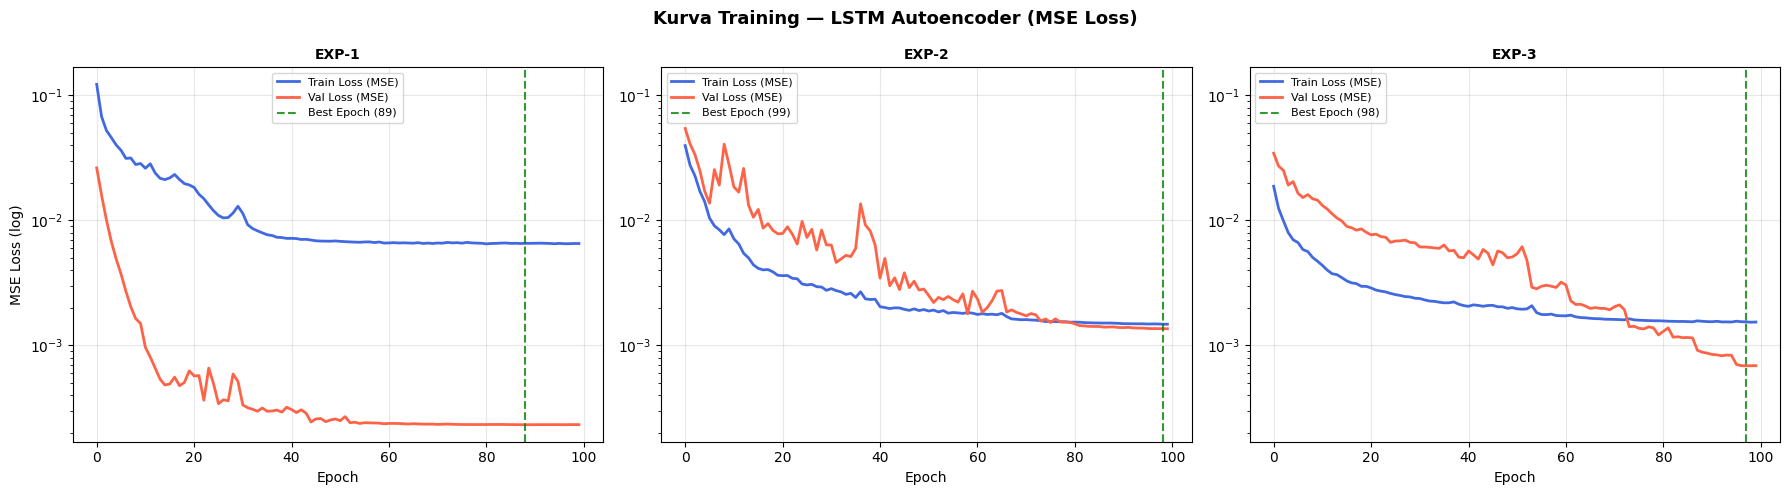


Plot disimpan: /kaggle/working/03_training_curves.png
Lanjut ke Bagian 4: EXP_MODELS siap digunakan untuk evaluasi.


In [13]:
# BAGIAN 03c — PLOT KURVA TRAINING
print("=" * 55)
print("  BAGIAN 03c — KURVA TRAINING")
print("=" * 55)

fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(6 * len(EXPERIMENTS), 5), sharey=True)
if len(EXPERIMENTS) == 1:
    axes = [axes]

for ax, exp_name in zip(axes, EXPERIMENTS):
    hist    = EXP_MODELS[exp_name]["history"].history
    best_ep = int(np.argmin(hist["val_loss"]))

    ax.plot(hist["loss"],     lw=2, color="royalblue", label="Train Loss (MSE)")
    ax.plot(hist["val_loss"], lw=2, color="tomato",    label="Val Loss (MSE)")
    ax.axvline(best_ep, color="green", ls="--", lw=1.5, alpha=0.8,
               label=f"Best Epoch ({best_ep + 1})")

    ax.set_title(exp_name.replace("_", " "), fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_yscale("log")
    ax.set_ylabel("MSE Loss (log)" if ax is axes[0] else "")
    ax.tick_params(labelleft=True)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    print(f"  [{exp_name}]  Best epoch: {best_ep + 1}  "
          f"| Val loss: {hist['val_loss'][best_ep]:.6f}  "
          f"| Train loss: {hist['loss'][best_ep]:.6f}")

fig.suptitle("Kurva Training — LSTM Autoencoder (MSE Loss)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, "03_training_curves.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPlot disimpan: {out_path}")
print("Lanjut ke Bagian 4: EXP_MODELS siap digunakan untuk evaluasi.")

# PART 4 - Evaluasi Model

## 4A - Rekonstruksi RE

In [14]:
# BAGIAN 04a — REKONSTRUKSI DATA DAN RECONSTRUCTION ERROR
def compute_re(original: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    """
    MSE Reconstruction Error per window.
    RE_i = mean((X_i - X̂_i)²) dirata-ratakan atas (timesteps, features).
    Satu nilai RE per window → anomaly score.
    """
    return np.mean((original - reconstructed) ** 2, axis=(1, 2))


print("=" * 55)
print("  BAGIAN 04a — REKONSTRUKSI DAN RECONSTRUCTION ERROR")
print("=" * 55)

EXP_RE = {}
for exp_name in EXPERIMENTS:
    model = EXP_MODELS[exp_name]["model"]
    prep  = EXP_PREP[exp_name]

    X_train_pred = model.predict(prep["X_train"], batch_size=BATCH_SIZE, verbose=0)
    X_val_pred   = model.predict(prep["X_val"],   batch_size=BATCH_SIZE, verbose=0)
    X_test_pred  = model.predict(prep["X_test"],  batch_size=BATCH_SIZE, verbose=0)

    re_train = compute_re(prep["X_train"], X_train_pred)
    re_val   = compute_re(prep["X_val"],   X_val_pred)
    re_test  = compute_re(prep["X_test"],  X_test_pred)

    EXP_RE[exp_name] = {
        "re_train": re_train,
        "re_val"  : re_val,
        "re_test" : re_test,
    }

    print(f"\n[{exp_name}]")
    print(f"  RE Train : mean={re_train.mean():.6f}  std={re_train.std():.6f}")
    print(f"  RE Val   : mean={re_val.mean():.6f}  std={re_val.std():.6f}")
    print(f"  RE Test  : mean={re_test.mean():.6f}  std={re_test.std():.6f}")

print("\nVariabel tersedia untuk 04b: EXP_RE")

  BAGIAN 04a — REKONSTRUKSI DAN RECONSTRUCTION ERROR

[EXP-1]
  RE Train : mean=0.002449  std=0.005583
  RE Val   : mean=0.000233  std=0.000138
  RE Test  : mean=5.860930  std=41.068848

[EXP-2]
  RE Train : mean=0.000425  std=0.001066
  RE Val   : mean=0.001362  std=0.005062
  RE Test  : mean=0.034784  std=0.076966

[EXP-3]
  RE Train : mean=0.000530  std=0.001047
  RE Val   : mean=0.000688  std=0.001732
  RE Test  : mean=0.015619  std=0.035947

Variabel tersedia untuk 04b: EXP_RE


## 4B - Penentuan Treshold

In [15]:
# BAGIAN 04b — PENENTUAN THRESHOLD

from scipy import stats

THRESHOLD_PERCENTILE = 95

print("=" * 55)
print("  BAGIAN 04b — PENENTUAN THRESHOLD")
print("=" * 55)
print(f"Metode : Persentil {THRESHOLD_PERCENTILE} dari RE data normal (train+val)")
print(f"Sumber : RE normal saja - label test tidak diakses")

# ------------------------------------------------------------
# STEP 1: Analisis distribusi RE untuk justifikasi pemilihan P95
# ------------------------------------------------------------
print("\n" + "-" * 55)
print("  Justifikasi threshold P95 — Analisis distribusi RE normal")
print("-" * 55)

skew_records = []
for exp_name in EXPERIMENTS:
    re_train  = EXP_RE[exp_name]["re_train"]
    re_val    = EXP_RE[exp_name]["re_val"]
    re_normal = np.concatenate([re_train, re_val])

    mean_re   = re_normal.mean()
    median_re = np.median(re_normal)
    std_re    = re_normal.std()
    skew_re   = stats.skew(re_normal)
    cv        = std_re / mean_re if mean_re > 0 else 0

    p50 = np.percentile(re_normal, 50)
    p95 = np.percentile(re_normal, 95)
    p99 = np.percentile(re_normal, 99)
    p_max = re_normal.max()

    ratio_p95 = p95 / median_re if median_re > 0 else 0
    ratio_p99 = p99 / median_re if median_re > 0 else 0

    if abs(skew_re) < 0.5:
        skew_interp = "approx. simetris"
    elif abs(skew_re) < 1.0:
        skew_interp = "moderately skewed"
    else:
        skew_interp = "highly skewed"

    skew_records.append({
        "Eksperimen"      : exp_name,
        "Mean RE"         : mean_re,
        "Median RE"       : median_re,
        "Std RE"          : std_re,
        "CV (std/mean)"   : cv,
        "Skewness"        : skew_re,
        "Interpretasi"    : skew_interp,
        "P95 (Threshold)" : p95,
        "P99"             : p99,
        "Max"             : p_max,
        "P95/Median"      : ratio_p95,
        "P99/Median"      : ratio_p99,
    })

df_skew = pd.DataFrame(skew_records)
print("\nTabel distribusi RE (normal train+val):")
print(df_skew.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

print("\nInterpretasi metrik distribusi:")
print("  - Skewness > 1.0    : distribusi right-skewed (tail panjang ke kanan)")
print("  - CV > 1.0          : variabilitas > lokasi (distribusi berat di tail)")
print("  - P95/Median >> 1   : threshold mean+kσ tidak stabil karena bias oleh tail")
print("  - P99/Median >> 1   : ekor distribusi ekstrem, quantile lebih robust")
print("\nKesimpulan:")
print("  Distribusi RE right-skewed → threshold berbasis percentile (P95) lebih robust")
print("  dibanding parametric (mean + kσ) yang mengasumsikan distribusi Gaussian.")

out_csv_skew = os.path.join(OUTPUT_DIR, "04b_distribusi_RE_normal.csv")
df_skew.to_csv(out_csv_skew, index=False)
print(f"\nCSV disimpan: {out_csv_skew}")

# ------------------------------------------------------------
# STEP 2: Set threshold berdasarkan justifikasi di atas
# ------------------------------------------------------------
print("\n" + "-" * 55)
print(f"  Threshold final (P{THRESHOLD_PERCENTILE})")
print("-" * 55)

EXP_THRESHOLD = {}
for exp_name in EXPERIMENTS:
    re_train  = EXP_RE[exp_name]["re_train"]
    re_val    = EXP_RE[exp_name]["re_val"]
    re_normal = np.concatenate([re_train, re_val])

    threshold = np.percentile(re_normal, THRESHOLD_PERCENTILE)
    fpr_val   = np.mean(re_val >= threshold)

    EXP_THRESHOLD[exp_name] = {
        "threshold": threshold,
        "re_normal": re_normal,
        "fpr_val"  : fpr_val,
    }

    print(f"\n[{exp_name}]")
    print(f"  RE normal : mean={re_normal.mean():.6f}  std={re_normal.std():.6f}")
    print(f"  Threshold : {threshold:.6f}")
    print(f"  FPR val   : {fpr_val*100:.1f}%  (normal yang salah diklasifikasi)")

print("\nVariabel tersedia untuk 04c: EXP_THRESHOLD")


  BAGIAN 04b — PENENTUAN THRESHOLD
Metode : Persentil 95 dari RE data normal (train+val)
Sumber : RE normal saja - label test tidak diakses

-------------------------------------------------------
  Justifikasi threshold P95 — Analisis distribusi RE normal
-------------------------------------------------------

Tabel distribusi RE (normal train+val):
Eksperimen  Mean RE  Median RE   Std RE  CV (std/mean)  Skewness  Interpretasi  P95 (Threshold)      P99      Max  P95/Median  P99/Median
     EXP-1 0.002025   0.000526 0.005096       2.516163  6.348941 highly skewed         0.007648 0.034073 0.047800   14.540638   64.781799
     EXP-2 0.000606   0.000163 0.002450       4.042053  9.118127 highly skewed         0.001233 0.010312 0.031390    7.549224   63.136242
     EXP-3 0.000561   0.000300 0.001212       2.160807  9.014555 highly skewed         0.001610 0.006586 0.028811    5.368044   21.966061

Interpretasi metrik distribusi:
  - Skewness > 1.0    : distribusi right-skewed (tail panjang

## 4C - Metrik Evaluasi

In [16]:
# BAGIAN 04c — METRIK EVALUASI (REVISI)

def apply_point_adjustment(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """PA: jika ada >=1 TP dalam satu segmen anomali kontinu,
    seluruh segmen dianggap terdeteksi."""
    y_pred_pa = y_pred.copy()
    i = 0
    while i < len(y_true):
        if y_true[i] == 1:
            j = i
            while j < len(y_true) and y_true[j] == 1:
                j += 1
            if y_pred[i:j].sum() > 0:
                y_pred_pa[i:j] = 1
            i = j
        else:
            i += 1
    return y_pred_pa


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, re_scores: np.ndarray) -> dict:
    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "accuracy" : accuracy_score(y_true, y_pred),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, re_scores)
        metrics["pr_auc"]  = average_precision_score(y_true, re_scores)
    except ValueError:
        metrics["roc_auc"] = float("nan")
        metrics["pr_auc"]  = float("nan")

    y_pred_pa = apply_point_adjustment(y_true, y_pred)
    metrics["f1_pa"]     = f1_score(y_true, y_pred_pa, zero_division=0)
    metrics["recall_pa"] = recall_score(y_true, y_pred_pa, zero_division=0)
    return metrics


print("=" * 55)
print("  BAGIAN 04c — METRIK EVALUASI")
print("=" * 55)

EXP_EVAL = {}
for exp_name in EXPERIMENTS:
    re_test   = EXP_RE[exp_name]["re_test"]
    threshold = EXP_THRESHOLD[exp_name]["threshold"]
    y_true    = EXP_PREP[exp_name]["y_test_seq"]
    meta      = EXP_PREP[exp_name]["meta_test"].copy()

    y_pred  = (re_test >= threshold).astype(int)
    metrics = compute_metrics(y_true, y_pred, re_test)

    meta["re_score"] = re_test
    meta["y_pred"]   = y_pred
    meta["y_true"]   = y_true

    EXP_EVAL[exp_name] = {
        "metrics"  : metrics,
        "y_pred"   : y_pred,
        "y_true"   : y_true,
        "meta_test": meta,
    }

    print(f"\n[{exp_name}]  threshold={threshold:.6f}")
    print(f"  [1] Pointwise (utama)")
    print(f"      Precision : {metrics['precision']:.4f}")
    print(f"      Recall    : {metrics['recall']:.4f}")
    print(f"      F1        : {metrics['f1']:.4f}")
    print(f"      ROC-AUC   : {metrics['roc_auc']:.4f}")
    print(f"      PR-AUC    : {metrics['pr_auc']:.4f}")
    print(f"  [2] PA-adjusted (pelengkap, level event)")
    print(f"      F1-PA     : {metrics['f1_pa']:.4f}")
    print(f"      Recall-PA : {metrics['recall_pa']:.4f}")

print("\nVariabel tersedia untuk 04d dan Bagian 5: EXP_EVAL")

  BAGIAN 04c — METRIK EVALUASI

[EXP-1]  threshold=0.007648
  [1] Pointwise (utama)
      Precision : 0.4170
      Recall    : 0.9634
      F1        : 0.5820
      ROC-AUC   : 0.6465
      PR-AUC    : 0.5084
  [2] PA-adjusted (pelengkap, level event)
      F1-PA     : 0.5975
      Recall-PA : 1.0000

[EXP-2]  threshold=0.001233
  [1] Pointwise (utama)
      Precision : 0.4942
      Recall    : 0.7922
      F1        : 0.6087
      ROC-AUC   : 0.5832
      PR-AUC    : 0.4367
  [2] PA-adjusted (pelengkap, level event)
      F1-PA     : 0.7115
      Recall-PA : 1.0000

[EXP-3]  threshold=0.001610
  [1] Pointwise (utama)
      Precision : 0.5128
      Recall    : 0.7774
      F1        : 0.6179
      ROC-AUC   : 0.6088
      PR-AUC    : 0.4402
  [2] PA-adjusted (pelengkap, level event)
      F1-PA     : 0.7303
      Recall-PA : 1.0000

Variabel tersedia untuk 04d dan Bagian 5: EXP_EVAL


## 4D - Confusion Matrix, Classification Report and Kurva ROC/PR

  BAGIAN 04d — CONFUSION MATRIX & CLASSIFICATION REPORT


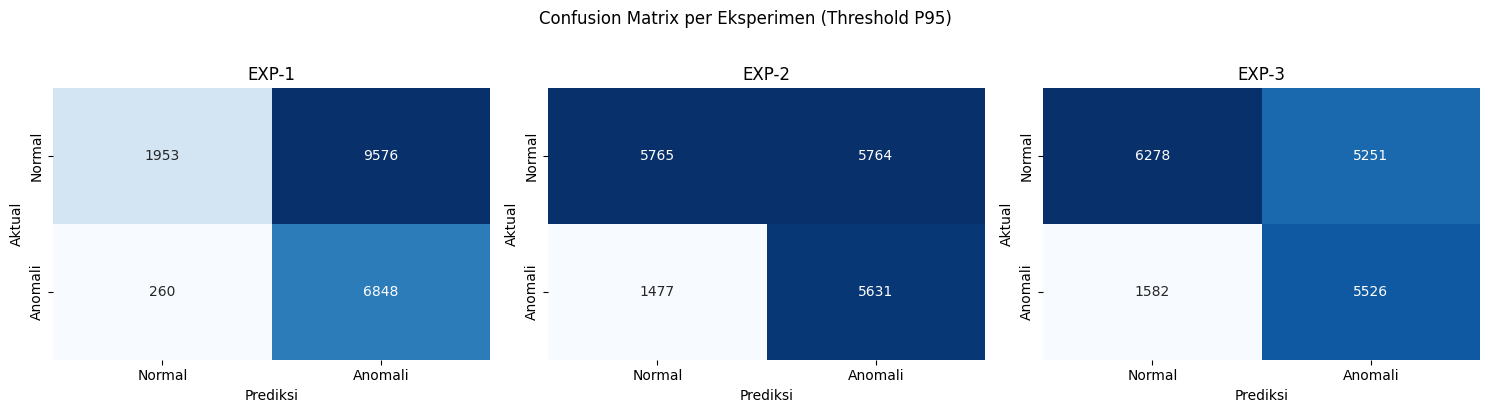


[EXP-1] Classification Report
              precision    recall  f1-score   support

      Normal       0.88      0.17      0.28     11529
     Anomali       0.42      0.96      0.58      7108

    accuracy                           0.47     18637
   macro avg       0.65      0.57      0.43     18637
weighted avg       0.70      0.47      0.40     18637


[EXP-2] Classification Report
              precision    recall  f1-score   support

      Normal       0.80      0.50      0.61     11529
     Anomali       0.49      0.79      0.61      7108

    accuracy                           0.61     18637
   macro avg       0.65      0.65      0.61     18637
weighted avg       0.68      0.61      0.61     18637


[EXP-3] Classification Report
              precision    recall  f1-score   support

      Normal       0.80      0.54      0.65     11529
     Anomali       0.51      0.78      0.62      7108

    accuracy                           0.63     18637
   macro avg       0.66      0.66  

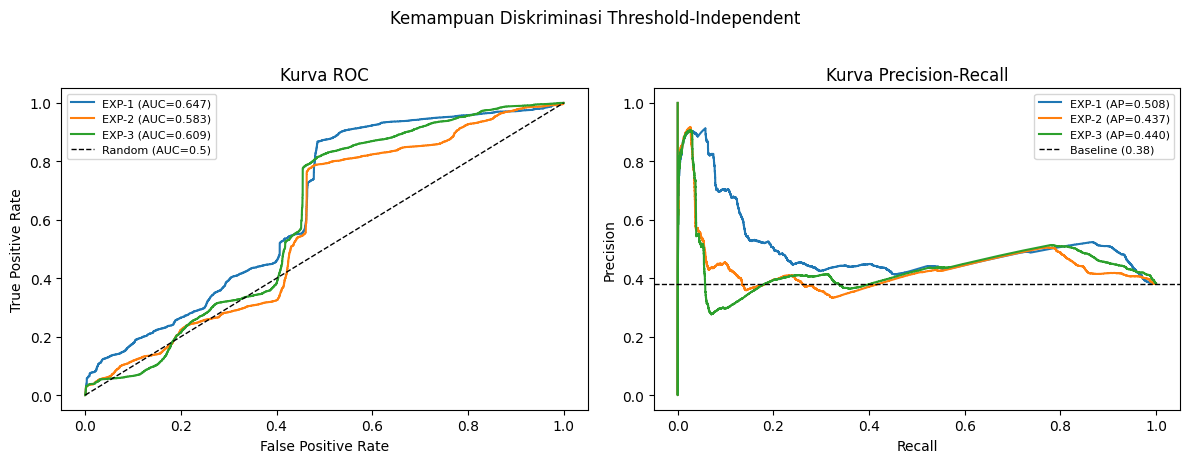

In [17]:
# BAGIAN 04d — CONFUSION MATRIX, CLASSIFICATION REPORT, KURVA ROC/PR (REVISI)
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, precision_recall_curve)

print("=" * 55)
print("  BAGIAN 04d — CONFUSION MATRIX & CLASSIFICATION REPORT")
print("=" * 55)

# Figur 1: Confusion matrix (konten analisis f.4)
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(5 * len(EXPERIMENTS), 4))
if len(EXPERIMENTS) == 1:
    axes = [axes]

for ax, exp_name in zip(axes, EXPERIMENTS):
    ev = EXP_EVAL[exp_name]
    cm = confusion_matrix(ev["y_true"], ev["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Anomali"],
                yticklabels=["Normal", "Anomali"])
    ax.set_title(f"{exp_name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

fig.suptitle("Confusion Matrix per Eksperimen (Threshold P95)", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/04d_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Classification report (pasangan confusion matrix, sesuai f.4)
for exp_name in EXPERIMENTS:
    ev = EXP_EVAL[exp_name]
    print(f"\n[{exp_name}] Classification Report")
    print(classification_report(ev["y_true"], ev["y_pred"],
                                target_names=["Normal", "Anomali"],
                                zero_division=0))

# Figur 2: Kurva ROC & PR (pendukung ROC-AUC/PR-AUC, threshold-independent) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for exp_name in EXPERIMENTS:
    ev = EXP_EVAL[exp_name]
    re_scores = ev["meta_test"]["re_score"].values
    m = ev["metrics"]

    fpr, tpr, _ = roc_curve(ev["y_true"], re_scores)
    ax1.plot(fpr, tpr, label=f"{exp_name} (AUC={m['roc_auc']:.3f})")

    prec, rec, _ = precision_recall_curve(ev["y_true"], re_scores)
    ax2.plot(rec, prec, label=f"{exp_name} (AP={m['pr_auc']:.3f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Kurva ROC")
ax1.legend(fontsize=8)

exp_pertama = next(iter(EXPERIMENTS))
base_rate = float(np.mean(EXP_EVAL[exp_pertama]["y_true"]))
ax2.axhline(base_rate, color="k", ls="--", lw=1,
            label=f"Baseline ({base_rate:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Kurva Precision-Recall")
ax2.legend(fontsize=8)

fig.suptitle("Kemampuan Diskriminasi Threshold-Independent", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/04d_roc_pr_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

# PART 5 - Analisis Hasil

## 5A - Distribusi RE

  BAGIAN 05a — DISTRIBUSI RECONSTRUCTION ERROR

[EXP-1]
  Median RE val          : 0.000173
  Median RE test-normal  : 0.026708
  Median RE test-anomali : 0.091955
  Rasio anomali/val      : 530.74x
  Rasio test-normal/val  : 154.15x  (>1 mengindikasikan domain shift)

[EXP-2]
  Median RE val          : 0.000113
  Median RE test-normal  : 0.001232
  Median RE test-anomali : 0.005179
  Rasio anomali/val      : 45.72x
  Rasio test-normal/val  : 10.87x  (>1 mengindikasikan domain shift)

[EXP-3]
  Median RE val          : 0.000235
  Median RE test-normal  : 0.000620
  Median RE test-anomali : 0.003962
  Rasio anomali/val      : 16.87x
  Rasio test-normal/val  : 2.64x  (>1 mengindikasikan domain shift)


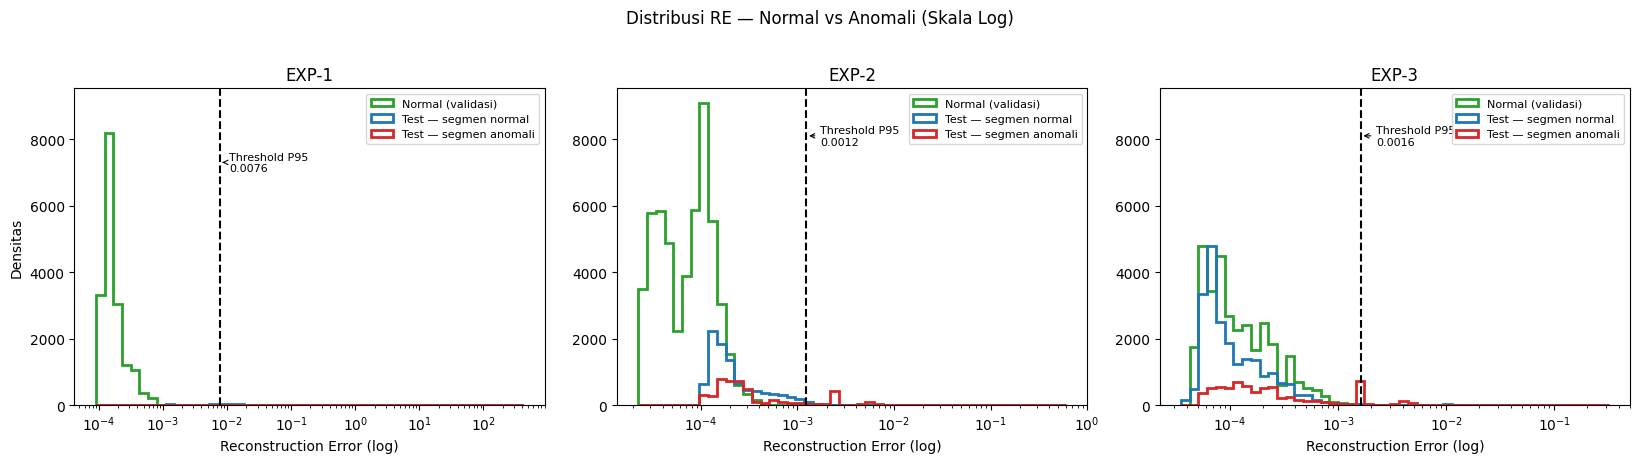

In [18]:
# BAGIAN 05a — ANALISIS DISTRIBUSI RECONSTRUCTION ERROR 
print("=" * 55)
print("  BAGIAN 05a — DISTRIBUSI RECONSTRUCTION ERROR")
print("=" * 55)

fig, axes = plt.subplots(1, len(EXPERIMENTS),
                         figsize=(5.5 * len(EXPERIMENTS), 4.5),
                         sharey=True)
if len(EXPERIMENTS) == 1:
    axes = [axes]

for ax, exp_name in zip(axes, EXPERIMENTS):
    re_val    = EXP_RE[exp_name]["re_val"]
    meta      = EXP_EVAL[exp_name]["meta_test"]
    threshold = EXP_THRESHOLD[exp_name]["threshold"]

    re_test_norm = meta.loc[meta["y_true"] == 0, "re_score"].values
    re_test_anom = meta.loc[meta["y_true"] == 1, "re_score"].values

    # Bin logaritmik untuk menangani rentang RE lebar
    all_re = np.concatenate([re_val, re_test_norm, re_test_anom])
    lo = max(all_re[all_re > 0].min(), 1e-8)
    hi = all_re.max()
    bins = np.logspace(np.log10(lo), np.log10(hi), 50)

    # Step histogram (outline) — tiga distribusi terlihat tanpa saling menutupi
    ax.hist(re_val, bins=bins, density=True,
            histtype="step", linewidth=2.0,
            color="tab:green", label="Normal (validasi)")
    ax.hist(re_test_norm, bins=bins, density=True,
            histtype="step", linewidth=2.0,
            color="tab:blue", label="Test — segmen normal")
    ax.hist(re_test_anom, bins=bins, density=True,
            histtype="step", linewidth=2.0,
            color="tab:red", label="Test — segmen anomali")

    # Threshold dianotasi langsung di plot
    ax.axvline(threshold, color="k", ls="--", lw=1.5)
    ymax = ax.get_ylim()[1]
    ax.annotate(f"Threshold P95\n{threshold:.4f}",
                xy=(threshold, ymax * 0.85),
                xytext=(threshold * 1.4, ymax * 0.85),
                fontsize=8, ha="left", va="center",
                arrowprops=dict(arrowstyle="->", lw=0.8))

    ax.set_xscale("log")
    ax.set_xlabel("Reconstruction Error (log)")
    ax.set_ylabel("Densitas" if ax is axes[0] else "")
    ax.tick_params(labelleft=True)
    ax.set_title(exp_name)
    ax.legend(fontsize=8, loc="upper right")

    print(f"\n[{exp_name}]")
    print(f"  Median RE val          : {np.median(re_val):.6f}")
    print(f"  Median RE test-normal  : {np.median(re_test_norm):.6f}")
    print(f"  Median RE test-anomali : {np.median(re_test_anom):.6f}")
    print(f"  Rasio anomali/val      : "
          f"{np.median(re_test_anom)/np.median(re_val):.2f}x")
    print(f"  Rasio test-normal/val  : "
          f"{np.median(re_test_norm)/np.median(re_val):.2f}x  "
          f"(>1 mengindikasikan domain shift)")

fig.suptitle("Distribusi RE — Normal vs Anomali (Skala Log)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05a_distribusi_re_log.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 5B - Treshold Sensitivity

  BAGIAN 05b — SENSITIVITAS THRESHOLD

-------------------------------------------------------
  [A] Tabel diskrit — Metrik per percentile per eksperimen
-------------------------------------------------------

[EXP-1]
Percentile  Threshold  Precision  Recall     F1  F1-PA      Status
       P70     0.0012     0.3811  0.9986 0.5516 0.5522  diagnostik
       P80     0.0025     0.3850  0.9921 0.5547 0.5579  diagnostik
       P90     0.0044     0.3872  0.9811 0.5553 0.5630  diagnostik
       P95     0.0076     0.4170  0.9634 0.5820 0.5975 OPERASIONAL

[EXP-2]
Percentile  Threshold  Precision  Recall     F1  F1-PA      Status
       P70     0.0003     0.4148  0.8792 0.5637 0.6173  diagnostik
       P80     0.0004     0.4227  0.8557 0.5659 0.6312  diagnostik
       P90     0.0007     0.4514  0.8293 0.5846 0.6649  diagnostik
       P95     0.0012     0.4942  0.7922 0.6087 0.7115 OPERASIONAL

[EXP-3]
Percentile  Threshold  Precision  Recall     F1  F1-PA      Status
       P70     0.0005     

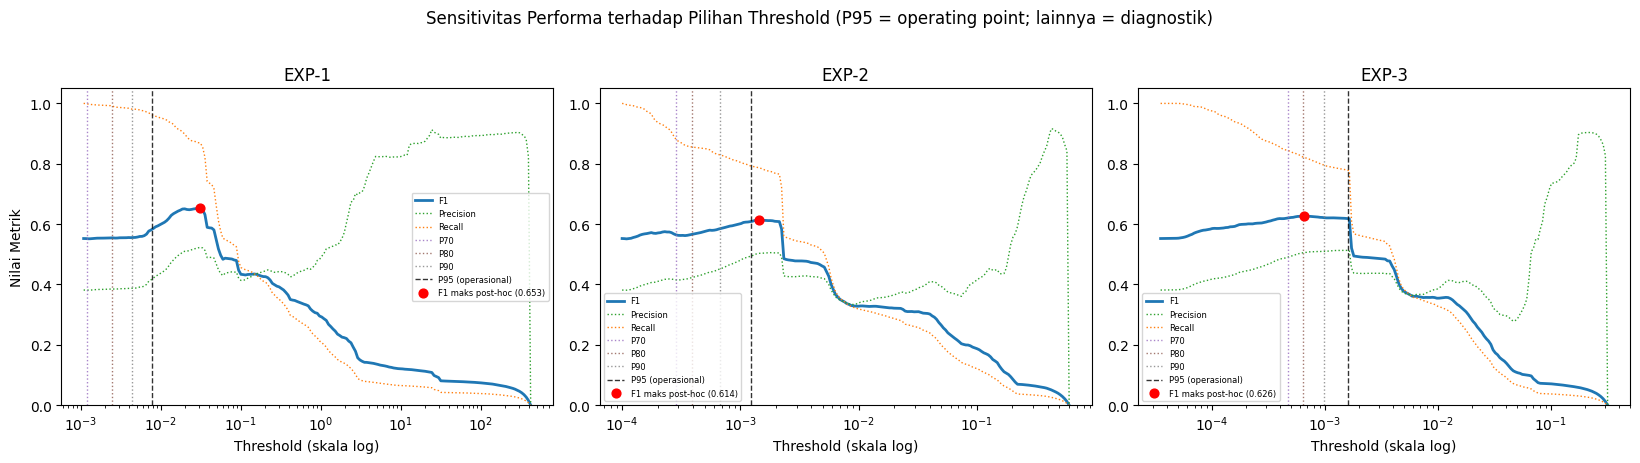


-------------------------------------------------------
  [C] Kesimpulan sensitivitas
-------------------------------------------------------

Ringkasan gap terhadap F1 maksimum post-hoc:
Eksperimen  Thr P95  F1 @ P95  Thr F1 maks  F1 maks post-hoc  Gap F1
     EXP-1   0.0076    0.5820       0.0312            0.6530  0.0710
     EXP-2   0.0012    0.6087       0.0014            0.6136  0.0050
     EXP-3   0.0016    0.6179       0.0007            0.6261  0.0081

Rentang F1 lintas percentile diskrit (P70–P95):
  EXP-1: F1 ∈ [0.5516, 0.5820]  (rentang = 0.0304)
  EXP-2: F1 ∈ [0.5637, 0.6087]  (rentang = 0.0450)
  EXP-3: F1 ∈ [0.6179, 0.6260]  (rentang = 0.0081)

Interpretasi (untuk BAB III):
  - Rentang F1 lintas P70–P95 relatif sempit dibanding F1 maks post-hoc,
    mengindikasikan bahwa pilihan threshold BUKAN faktor utama pembatas performa.
  - Trade-off Precision-Recall bergerak proporsional: recall meningkat pada
    percentile lebih rendah dengan penurunan precision yang sebanding.


In [19]:
# BAGIAN 05b — ANALISIS PENGARUH THRESHOLD TERHADAP HASIL DETEKSI

print("=" * 55)
print("  BAGIAN 05b — SENSITIVITAS THRESHOLD")
print("=" * 55)

# BAGIAN A — TABEL DISKRIT P70/P80/P90/P95

CANDIDATE_PERCENTILES = [70, 80, 90, 95]

print("\n" + "-" * 55)
print("  [A] Tabel diskrit — Metrik per percentile per eksperimen")
print("-" * 55)

records_diskrit = []
for exp_name in EXPERIMENTS:
    ev        = EXP_EVAL[exp_name]
    y_true    = ev["y_true"]
    re_test   = ev["meta_test"]["re_score"].values
    re_normal = EXP_THRESHOLD[exp_name]["re_normal"]

    for p in CANDIDATE_PERCENTILES:
        thr = np.percentile(re_normal, p)
        y_pred = (re_test >= thr).astype(int)

        prec   = precision_score(y_true, y_pred, zero_division=0)
        rec    = recall_score(y_true, y_pred, zero_division=0)
        f1     = f1_score(y_true, y_pred, zero_division=0)

        y_pred_pa = apply_point_adjustment(y_true, y_pred)
        f1_pa     = f1_score(y_true, y_pred_pa, zero_division=0)
        rec_pa    = recall_score(y_true, y_pred_pa, zero_division=0)

        records_diskrit.append({
            "Eksperimen"   : exp_name,
            "Percentile"   : f"P{p}",
            "Threshold"    : thr,
            "Precision"    : prec,
            "Recall"       : rec,
            "F1"           : f1,
            "F1-PA"        : f1_pa,
            "Recall-PA"    : rec_pa,
            "Status"       : "OPERASIONAL" if p == 95 else "diagnostik",
        })

df_diskrit = pd.DataFrame(records_diskrit)

# Tampilkan tabel per eksperimen agar mudah dibaca
for exp_name in EXPERIMENTS:
    sub = df_diskrit[df_diskrit["Eksperimen"] == exp_name].copy()
    print(f"\n[{exp_name}]")
    print(sub[["Percentile", "Threshold", "Precision", "Recall",
               "F1", "F1-PA", "Status"]].to_string(
        index=False,
        float_format=lambda v: f"{v:.4f}"
    ))

# Simpan CSV untuk kutipan di BAB III
out_csv_diskrit = os.path.join(OUTPUT_DIR, "05b_sensitivitas_threshold_diskrit.csv")
df_diskrit.to_csv(out_csv_diskrit, index=False)
print(f"\nCSV disimpan: {out_csv_diskrit}")

# BAGIAN B — SWEEP CONTINUOUS + PLOT

print("\n" + "-" * 55)
print("  [B] Sweep continuous — Visualisasi trade-off Precision-Recall-F1")
print("-" * 55)

fig, axes = plt.subplots(1, len(EXPERIMENTS),
                         figsize=(5.5 * len(EXPERIMENTS), 4.5),
                         sharey=True)
if len(EXPERIMENTS) == 1:
    axes = [axes]

ringkasan_sweep = []
for ax, exp_name in zip(axes, EXPERIMENTS):
    ev        = EXP_EVAL[exp_name]
    y_true    = ev["y_true"]
    re_scores = ev["meta_test"]["re_score"].values
    re_normal = EXP_THRESHOLD[exp_name]["re_normal"]
    thr_p95   = EXP_THRESHOLD[exp_name]["threshold"]

    lo = max(re_scores[re_scores > 0].min(), 1e-8)
    hi = re_scores.max()
    kandidat = np.logspace(np.log10(lo), np.log10(hi), 200)

    f1s, precs, recs = [], [], []
    for t in kandidat:
        y_p = (re_scores >= t).astype(int)
        f1s.append(f1_score(y_true, y_p, zero_division=0))
        precs.append(precision_score(y_true, y_p, zero_division=0))
        recs.append(recall_score(y_true, y_p, zero_division=0))
    f1s = np.array(f1s)

    idx_opt = int(f1s.argmax())
    f1_p95  = ev["metrics"]["f1"]

    # Kurva metrik
    ax.plot(kandidat, f1s,   label="F1",        color="tab:blue",   lw=2)
    ax.plot(kandidat, precs, label="Precision", color="tab:green",  lw=1, ls=":")
    ax.plot(kandidat, recs,  label="Recall",    color="tab:orange", lw=1, ls=":")

    # Tandai keempat percentile diskrit sebagai vertical line
    warna_p = {70: "tab:purple", 80: "tab:brown", 90: "tab:gray", 95: "black"}
    for p in CANDIDATE_PERCENTILES:
        thr_p  = np.percentile(re_normal, p)
        style  = "--" if p == 95 else ":"
        label  = f"P{p}"  + (" (operasional)" if p == 95 else "")
        ax.axvline(thr_p, color=warna_p[p], ls=style, lw=1.0, alpha=0.8,
                   label=label)

    # F1 maks post-hoc (untuk narasi separabilitas)
    ax.scatter([kandidat[idx_opt]], [f1s[idx_opt]],
               color="red", zorder=5, s=40,
               label=f"F1 maks post-hoc ({f1s[idx_opt]:.3f})")

    ax.set_xscale("log")
    ax.set_xlabel("Threshold (skala log)")
    ax.set_ylabel("Nilai Metrik" if ax is axes[0] else "")
    ax.tick_params(labelleft=True)
    ax.set_ylim(0, 1.05)
    ax.set_title(exp_name)
    ax.legend(fontsize=6, loc="best")

    ringkasan_sweep.append({
        "Eksperimen"       : exp_name,
        "Thr P95"          : thr_p95,
        "F1 @ P95"         : f1_p95,
        "Thr F1 maks"      : kandidat[idx_opt],
        "F1 maks post-hoc" : f1s[idx_opt],
        "Gap F1"           : f1s[idx_opt] - f1_p95,
    })

fig.suptitle("Sensitivitas Performa terhadap Pilihan Threshold "
             "(P95 = operating point; lainnya = diagnostik)", y=1.02)
plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, "05b_threshold_sensitivity.png")
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()

# BAGIAN C — KESIMPULAN SENSITIVITAS

print("\n" + "-" * 55)
print("  [C] Kesimpulan sensitivitas")
print("-" * 55)

df_sweep = pd.DataFrame(ringkasan_sweep)
print("\nRingkasan gap terhadap F1 maksimum post-hoc:")
print(df_sweep.to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

# Rentang F1 lintas percentile diskrit per eksperimen (untuk kalimat BAB III)
print("\nRentang F1 lintas percentile diskrit (P70–P95):")
for exp_name in EXPERIMENTS:
    sub  = df_diskrit[df_diskrit["Eksperimen"] == exp_name]
    f1_min = sub["F1"].min()
    f1_max = sub["F1"].max()
    print(f"  {exp_name}: F1 ∈ [{f1_min:.4f}, {f1_max:.4f}]  "
          f"(rentang = {f1_max - f1_min:.4f})")

print("\nInterpretasi (untuk BAB III):")
print("  - Rentang F1 lintas P70–P95 relatif sempit dibanding F1 maks post-hoc,")
print("    mengindikasikan bahwa pilihan threshold BUKAN faktor utama pembatas performa.")
print("  - Trade-off Precision-Recall bergerak proporsional: recall meningkat pada")
print("    percentile lebih rendah dengan penurunan precision yang sebanding.")
print("  - Ceiling F1 maks post-hoc mencerminkan batas separabilitas reconstruction")
print("    error akibat domain shift antara data working condition dan test anomaly.")

out_csv_sweep = os.path.join(OUTPUT_DIR, "05b_sensitivitas_threshold_sweep.csv")
df_sweep.to_csv(out_csv_sweep, index=False)
print(f"\nCSV disimpan: {out_csv_sweep}")

## 5C - Performa per Jenis Anomali

  BAGIAN 05c — PERFORMA PER JENIS ANOMALI


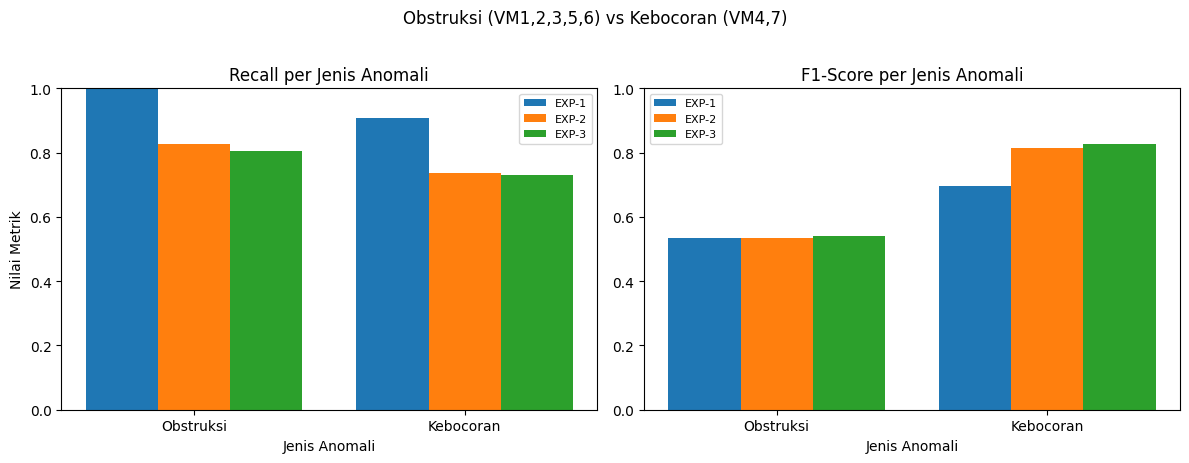


Tabel per jenis anomali:
Eksperimen     Jenis  Recall     F1  Median RE anomali
     EXP-1 Kebocoran  0.9084 0.6961             0.0505
     EXP-1 Obstruksi  0.9973 0.5331             0.3291
     EXP-2 Kebocoran  0.7373 0.8134             0.0054
     EXP-2 Obstruksi  0.8259 0.5348             0.0023
     EXP-3 Kebocoran  0.7311 0.8277             0.0042
     EXP-3 Obstruksi  0.8060 0.5414             0.0017

Rincian per valve (pendukung):
Eksperimen  EXP-1  EXP-2  EXP-3
Valve                          
VM1        0.8269 0.8974 0.9487
VM2        0.2647 0.2948 0.3064
VM3        0.4084 0.0942 0.0530
VM4        0.6785 0.6771 0.6827
VM5        0.3867 0.8865 0.9220
VM6        0.6433 0.6407 0.6386
VM7        0.7157 0.9412 0.9661


In [20]:
# BAGIAN 05c — ANALISIS PERFORMA BERDASARKAN JENIS ANOMALI
ANOMALY_TYPE = {
    "VM1": "Obstruksi", "VM2": "Obstruksi", "VM3": "Obstruksi",
    "VM5": "Obstruksi", "VM6": "Obstruksi",
    "VM4": "Kebocoran", "VM7": "Kebocoran",
}

print("=" * 55)
print("  BAGIAN 05c — PERFORMA PER JENIS ANOMALI")
print("=" * 55)

hasil_jenis = []
hasil_valve = []
for exp_name in EXPERIMENTS:
    meta = EXP_EVAL[exp_name]["meta_test"].copy()
    meta["jenis"] = meta["valve"].map(ANOMALY_TYPE)

    for jenis, grp in meta.groupby("jenis"):
        hasil_jenis.append({
            "Eksperimen": exp_name, "Jenis": jenis,
            "Recall": recall_score(grp["y_true"], grp["y_pred"],
                                   zero_division=0),
            "F1": f1_score(grp["y_true"], grp["y_pred"], zero_division=0),
            "Median RE anomali": grp.loc[grp["y_true"] == 1,
                                         "re_score"].median(),
        })
    for valve, grp in meta.groupby("valve"):
        hasil_valve.append({
            "Eksperimen": exp_name, "Valve": valve,
            "Jenis": ANOMALY_TYPE[valve],
            "Recall": recall_score(grp["y_true"], grp["y_pred"],
                                   zero_division=0),
            "F1": f1_score(grp["y_true"], grp["y_pred"], zero_division=0),
        })

df_jenis = pd.DataFrame(hasil_jenis)
df_valve = pd.DataFrame(hasil_valve)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
jenis_order = ["Obstruksi", "Kebocoran"]
x = np.arange(len(jenis_order))
w = 0.8 / len(EXPERIMENTS)

for i, exp_name in enumerate(EXPERIMENTS):
    sub = (df_jenis[df_jenis["Eksperimen"] == exp_name]
           .set_index("Jenis").reindex(jenis_order))
    ax1.bar(x + i * w, sub["Recall"], w, label=exp_name)
    ax2.bar(x + i * w, sub["F1"], w, label=exp_name)

for ax, judul in [(ax1, "Recall"), (ax2, "F1-Score")]:
    ax.set_xticks(x + w * (len(EXPERIMENTS) - 1) / 2)
    ax.set_xticklabels(jenis_order)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Jenis Anomali")
    ax.set_ylabel("Nilai Metrik" if ax is ax1 else "")
    ax.tick_params(labelleft=True)
    ax.set_title(f"{judul} per Jenis Anomali")
    ax.legend(fontsize=8)

fig.suptitle("Obstruksi (VM1,2,3,5,6) vs Kebocoran (VM4,7)", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/05c_per_jenis_anomali.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTabel per jenis anomali:")
print(df_jenis.to_string(index=False,
      float_format=lambda v: f"{v:.4f}"))
print("\nRincian per valve (pendukung):")
print(df_valve.pivot(index="Valve", columns="Eksperimen",
                     values="F1").to_string(
      float_format=lambda v: f"{v:.4f}"))

## 5E - Grafik RE terhadap Waktu

  BAGIAN 05e — RE TERHADAP WAKTU (STUDI KASUS REPRESENTATIF)

[EXP-1] F1 per file:
source_file
anomalyVM1_severe.xlsx   0.8269
anomalyVM7_severe.xlsx   0.7157
anomalyVM4_severe.xlsx   0.6785
anomalyVM6_severe.xlsx   0.6433
anomalyVM3_severe.xlsx   0.4084
anomalyVM5_severe.xlsx   0.3867
anomalyVM2_severe.xlsx   0.2647


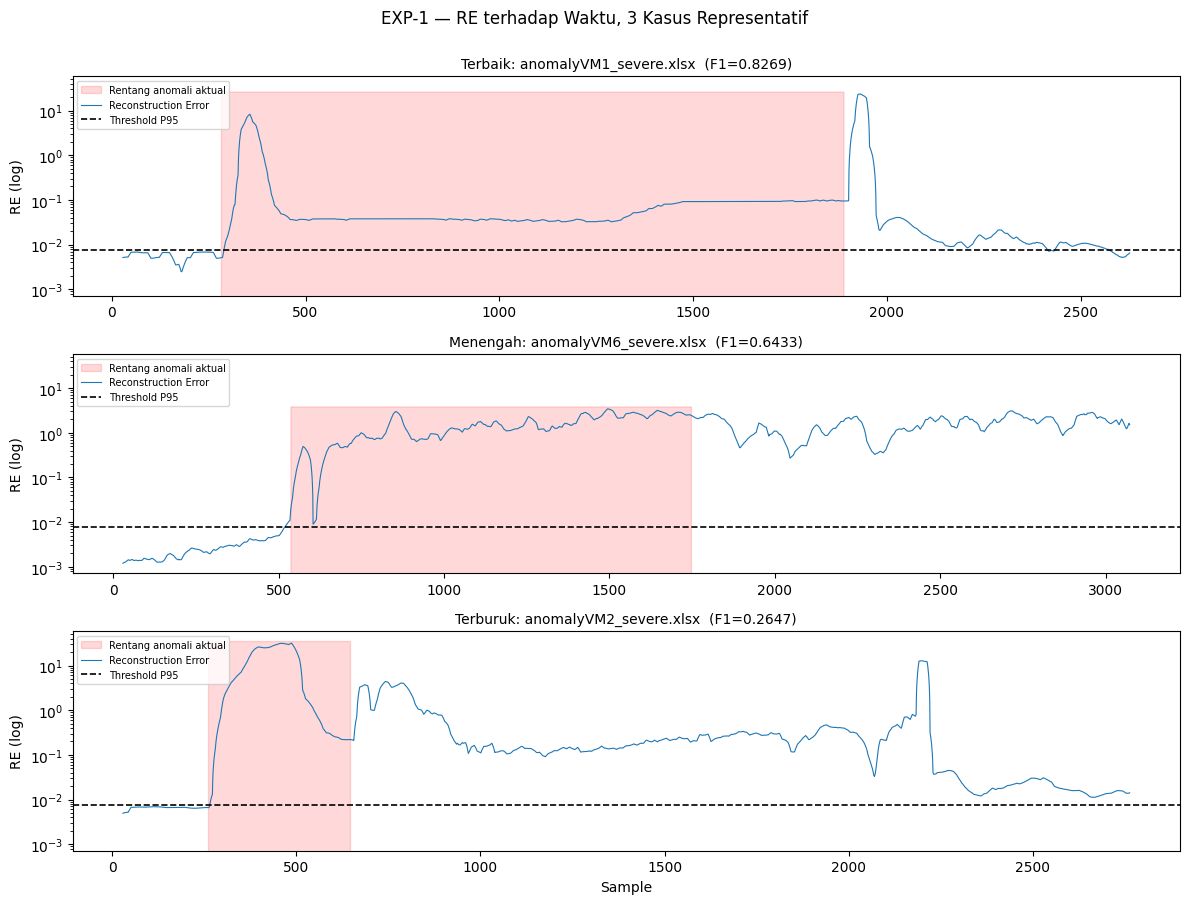


[EXP-2] F1 per file:
source_file
anomalyVM7_severe.xlsx   0.9412
anomalyVM1_severe.xlsx   0.8974
anomalyVM5_severe.xlsx   0.8865
anomalyVM4_severe.xlsx   0.6771
anomalyVM6_severe.xlsx   0.6407
anomalyVM2_severe.xlsx   0.2948
anomalyVM3_severe.xlsx   0.0942


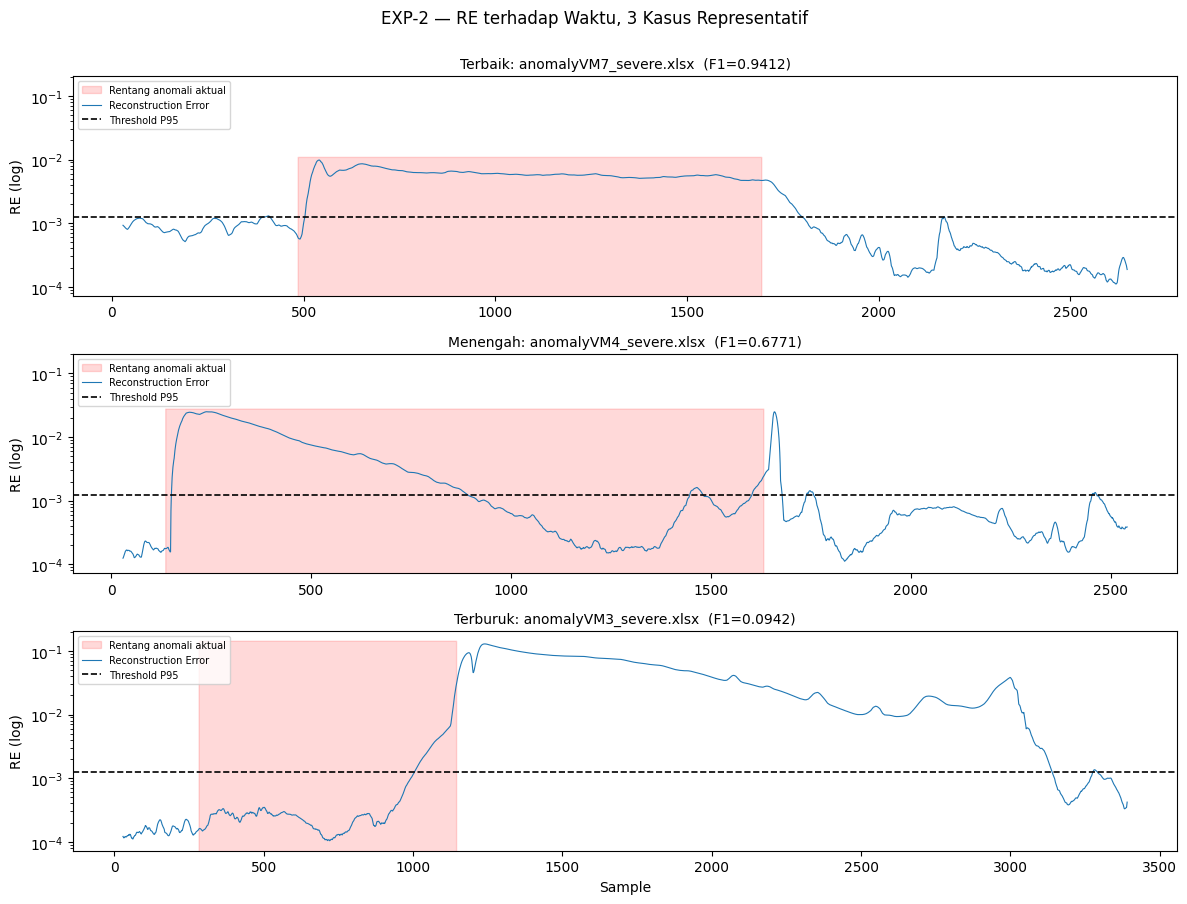


[EXP-3] F1 per file:
source_file
anomalyVM7_severe.xlsx   0.9661
anomalyVM1_severe.xlsx   0.9487
anomalyVM5_severe.xlsx   0.9220
anomalyVM4_severe.xlsx   0.6827
anomalyVM6_severe.xlsx   0.6386
anomalyVM2_severe.xlsx   0.3064
anomalyVM3_severe.xlsx   0.0530


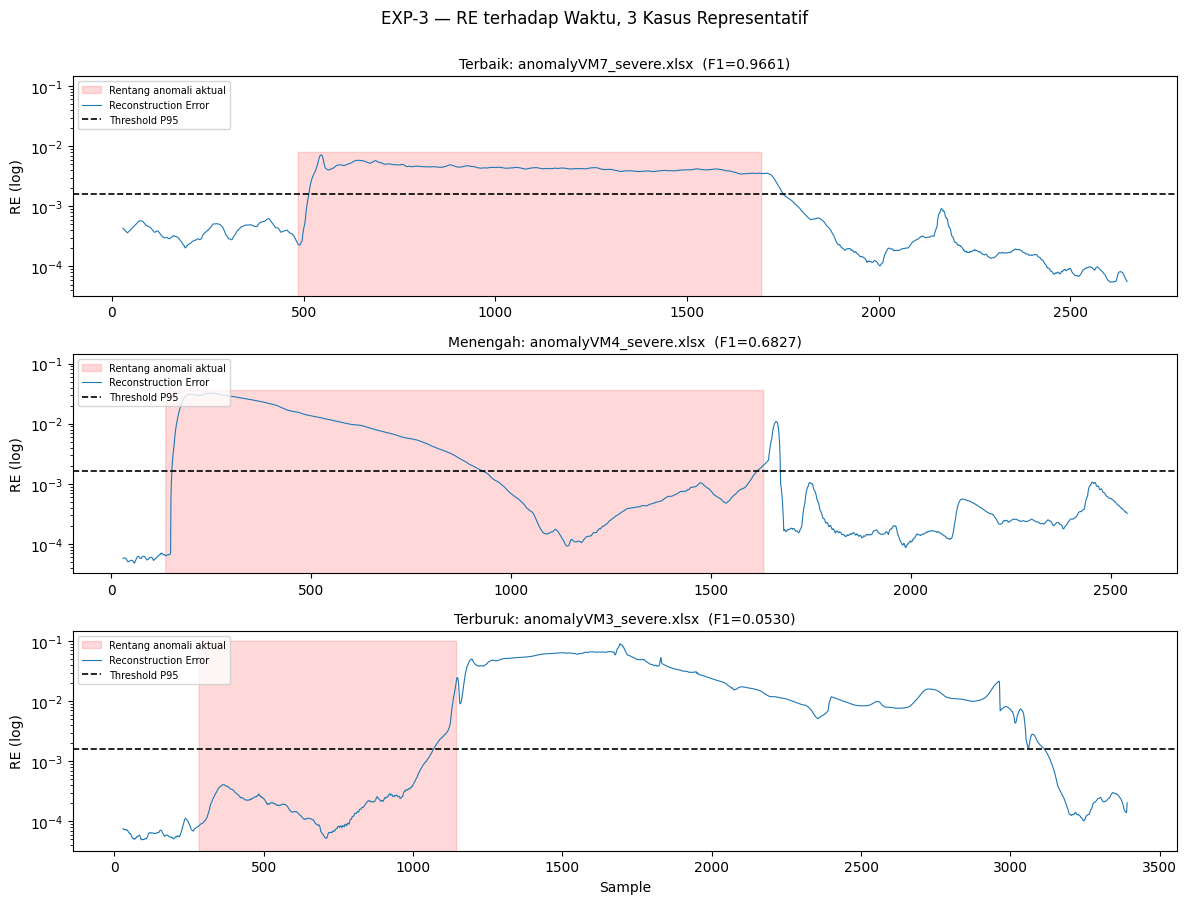

In [21]:
# BAGIAN 05e — GRAFIK RECONSTRUCTION ERROR TERHADAP WAKTU

print("=" * 55)
print("  BAGIAN 05e — RE TERHADAP WAKTU (STUDI KASUS REPRESENTATIF)")
print("=" * 55)

for exp_name in EXPERIMENTS:
    meta      = EXP_EVAL[exp_name]["meta_test"]
    threshold = EXP_THRESHOLD[exp_name]["threshold"]

    f1_file = (meta.groupby("source_file")
               .apply(lambda g: f1_score(g["y_true"], g["y_pred"],
                                         zero_division=0))
               .sort_values(ascending=False))

    print(f"\n[{exp_name}] F1 per file:")
    print(f1_file.to_string(float_format=lambda v: f"{v:.4f}"))

    terpilih = [
        ("Terbaik",   f1_file.index[0]),
        ("Menengah",  f1_file.index[len(f1_file) // 2]),
        ("Terburuk",  f1_file.index[-1]),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False, sharey=True)
    for ax, (kategori, fname) in zip(axes, terpilih):
        sub = meta[meta["source_file"] == fname].reset_index(drop=True)
        t = np.arange(len(sub)) + TIMESTEPS - 1

        anom_mask = sub["y_true"].values == 1
        ax.fill_between(t, 0, sub["re_score"].max() * 1.1,
                        where=anom_mask, color="red", alpha=0.15,
                        label="Rentang anomali aktual")
        ax.plot(t, sub["re_score"], lw=0.8, color="tab:blue",
                label="Reconstruction Error")
        ax.axhline(threshold, color="k", ls="--", lw=1.2,
                   label=f"Threshold P95")
        ax.set_yscale("log")
        ax.set_ylabel("RE (log)")
        ax.tick_params(labelleft=True)
        ax.set_title(f"{kategori}: {fname}  "
                     f"(F1={f1_file[fname]:.4f})", fontsize=10)
        ax.legend(fontsize=7, loc="upper left")

    axes[-1].set_xlabel("Sample")
    fig.suptitle(f"{exp_name} — RE terhadap Waktu, "
                 f"3 Kasus Representatif", y=1.00)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/05e_re_temporal_{exp_name}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 5F - Ringkasan

  BAGIAN 05f — RINGKASAN PERBANDINGAN EKSPERIMEN

Tabel ringkasan metrik utama (pointwise + threshold-independent):
            Threshold  Best ValLoss  Precision  Recall      F1  ROC-AUC  PR-AUC  Accuracy
Eksperimen                                                                               
EXP-1        0.007648      0.000233     0.4170  0.9634  0.5820   0.6465  0.5084    0.4722
EXP-2        0.001233      0.001362     0.4942  0.7922  0.6087   0.5832  0.4367    0.6115
EXP-3        0.001610      0.000688     0.5128  0.7774  0.6179   0.6088  0.4402    0.6334

CSV utama disimpan: /kaggle/working/05f_ringkasan_eksperimen.csv

------------------------------------------------------------
  LAMPIRAN — Metrik Point-Adjustment (PA)
------------------------------------------------------------
             F1-PA  Recall-PA
Eksperimen                   
EXP-1       0.5975        1.0
EXP-2       0.7115        1.0
EXP-3       0.7303        1.0

Catatan: PA dihitung untuk reversibility internal.
 

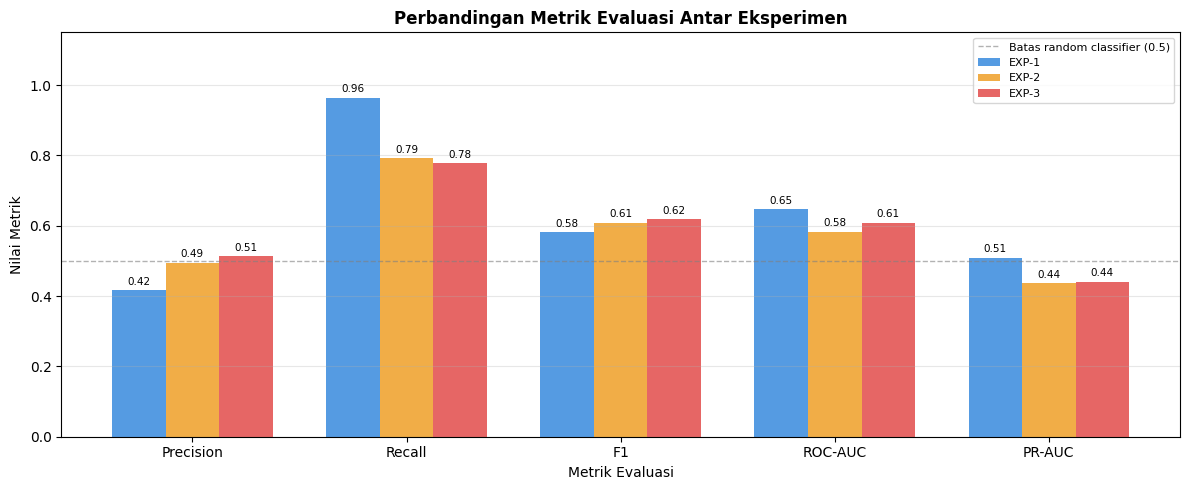


Plot disimpan: /kaggle/working/05f_perbandingan_eksperimen.png

Seluruh analisis Bagian 5 selesai.
Variabel yang dihasilkan:
  - CSV: 04b_distribusi_RE_normal.csv, 05c_valve_*.csv,
         05f_ringkasan_eksperimen.csv, 05f_lampiran_metrik_PA.csv
  - PNG: 03_training_curves.png, 04d_*.png, 05a-05f_*.png


In [22]:
# BAGIAN 05f — RINGKASAN DAN PERBANDINGAN ANTAR EKSPERIMEN
print("=" * 60)
print("  BAGIAN 05f — RINGKASAN PERBANDINGAN EKSPERIMEN")
print("=" * 60)

rows_main = []
for exp_name in EXPERIMENTS:
    ev   = EXP_EVAL[exp_name]
    hist = EXP_MODELS[exp_name]["history"].history
    m    = ev["metrics"]
    rows_main.append({
        "Eksperimen"  : exp_name,
        "Threshold"   : round(EXP_THRESHOLD[exp_name]["threshold"], 6),
        "Best ValLoss": round(min(hist["val_loss"]), 6),
        "Precision"   : round(m["precision"],  4),
        "Recall"      : round(m["recall"],     4),
        "F1"          : round(m["f1"],         4),
        "ROC-AUC"     : round(m["roc_auc"],    4),
        "PR-AUC"      : round(m["pr_auc"],     4),
        "Accuracy"    : round(m["accuracy"],   4),
    })

df_sum = pd.DataFrame(rows_main).set_index("Eksperimen")
print("\nTabel ringkasan metrik utama (pointwise + threshold-independent):")
print(df_sum.to_string())

out_csv = os.path.join(OUTPUT_DIR, "05f_ringkasan_eksperimen.csv")
df_sum.to_csv(out_csv)
print(f"\nCSV utama disimpan: {out_csv}")

# ------------------------------------------------------------
# TABEL LAMPIRAN — Metrik PA (Point-Adjustment)
# Dihitung untuk reversibility internal, tidak dilaporkan di draft
# ------------------------------------------------------------
rows_pa = []
for exp_name in EXPERIMENTS:
    m = EXP_EVAL[exp_name]["metrics"]
    rows_pa.append({
        "Eksperimen" : exp_name,
        "F1-PA"      : round(m["f1_pa"],      4),
        "Recall-PA"  : round(m["recall_pa"],  4),
    })

df_pa = pd.DataFrame(rows_pa).set_index("Eksperimen")
print("\n" + "-" * 60)
print("  LAMPIRAN — Metrik Point-Adjustment (PA)")
print("-" * 60)
print(df_pa.to_string())
print("\nCatatan: PA dihitung untuk reversibility internal.")
print("        Tidak dilaporkan sebagai metrik utama karena optimism bias")
print("        pada dataset dengan region anomali panjang (Bhattacharya et al., 2024).")

out_csv_pa = os.path.join(OUTPUT_DIR, "05f_lampiran_metrik_PA.csv")
df_pa.to_csv(out_csv_pa)
print(f"\nCSV lampiran PA disimpan: {out_csv_pa}")

# ------------------------------------------------------------
# BAR CHART — Metrik utama saja (tanpa PA)
# ------------------------------------------------------------
metrics_plot = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
x     = np.arange(len(metrics_plot))
width = 0.25
clrs  = ["#378ADD", "#EF9F27", "#E24B4A"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (exp_name, color) in enumerate(zip(EXPERIMENTS, clrs)):
    vals = [df_sum.loc[exp_name, m] for m in metrics_plot]
    ax.bar(x + i * width, vals, width,
           label=exp_name, color=color, alpha=0.85)
    for j, v in enumerate(vals):
        ax.text(x[j] + i * width, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=7.5, rotation=0)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Metrik Evaluasi")
ax.set_ylabel("Nilai Metrik")
ax.set_title("Perbandingan Metrik Evaluasi Antar Eksperimen",
             fontsize=12, fontweight="bold")
ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6,
           label="Batas random classifier (0.5)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_plot = os.path.join(OUTPUT_DIR, "05f_perbandingan_eksperimen.png")
plt.savefig(out_plot, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot disimpan: {out_plot}")
print("\nSeluruh analisis Bagian 5 selesai.")
print("Variabel yang dihasilkan:")
print("  - CSV: 04b_distribusi_RE_normal.csv, 05c_valve_*.csv,")
print("         05f_ringkasan_eksperimen.csv, 05f_lampiran_metrik_PA.csv")
print("  - PNG: 03_training_curves.png, 04d_*.png, 05a-05f_*.png")
